In [1]:
# from data_synthesizer.util import  plot_training_loss, ModelType
from data_loader import DataLoader
from data_synthesizer.sdv import SDVCTGAN_, SDVTVAE_
from data_evaluator import ClassifierType
from data_evaluator.privacy_evaluation import AnonymeterResults
from data_synthesizer.pipeline import PipelineBuilder, save_all_results, load_all_results


In [2]:
import sys
from pathlib import Path

# Add repo root so `import experiments` works in notebooks.
sys.path.append(str(Path.cwd().parent.parent))

from experiments.paths import GENERATOR_OPTIMIZATION_DIR, OPTUNA_DIR

## Save/Load Pipeline

### save generation

In [125]:
import numpy as np
import pandas as pd
import h5py
results = adult_ctgan_results_dict['adult_ctgan_eps_0.15']['generation_results']

# Save to HDF5
results['synthetic_data'].to_hdf('data_with_objects.h5', key='my_data', mode='w', format='table', complevel=9, complib='zlib')

# Save both DataFrames to the same HDF5 file
with pd.HDFStore('multiple_datasets.h5', mode='w') as store:
    store.put('synthetic_data', results['synthetic_data'], format='table', complevel=9, complib='zlib')  # Save df1 under the key 'dataset1'
    store.put('real_train_data', df_real_adult_train, format='table', complevel=9, complib='zlib') 

# with h5py.File('generation_results.h5', 'w') as hdf:
#     synth_data = results['synthetic_data']
#     hdf.create_dataset(f'synthetic_data', data=synth_data.values)
#     hdf[f'synthetic_data'].attrs['columns'] = synth_data.columns.tolist()
#     hdf[f'synthetic_data'].attrs['index'] = synth_data.index.tolist()

In [ ]:
with pd.HDFStore('multiple_datasets.h5', mode='r') as store:
    loaded_df1 = store['synthetic_data']  # Load the DataFrame stored under 'dataset1'
    loaded_df2 = store['real_train_data']  # Load the DataFrame stored under 'dataset2'

In [126]:
# File Sizes
import os
print("CSV File Size:", os.path.getsize('../../data/adult_train.csv') / 1e6, "MB")
print("HDF5 File Size:", os.path.getsize('data_with_objects.h5') / 1e6, "MB")
print("HDF5 File Size:", os.path.getsize('multiple_datasets.h5') / 1e6, "MB")

CSV File Size: 3.844217 MB
HDF5 File Size: 0.658554 MB
HDF5 File Size: 2.790899 MB


In [124]:
import unittest
import pandas as pd
import numpy as np
from pandas.testing import assert_frame_equal, assert_series_equal

class TestGenerationResults(unittest.TestCase):
    
    @classmethod
    def setUpClass(cls):
        """This method runs once before all tests."""

        cls.results = adult_ctgan_results_dict['adult_ctgan_eps_0.15']['generation_results']


    def test_synthetic_data_equality(self):
        # Assert that both DataFrames are equal (using initialized df1 and df2)
        df_expected = results['synthetic_data']
        loaded_df = pd.read_hdf('data_with_objects.h5', key='my_data')

        assert_frame_equal(df_expected, loaded_df)

    def test_synthetic_data_equality_2(self):
        # Assert that both DataFrames are equal (using initialized df1 and df2)
        df_expected = results['synthetic_data']
        with pd.HDFStore('multiple_datasets.h5', mode='r') as store:
            loaded_df1 = store['synthetic_data']  # Load the DataFrame stored under 'dataset1'
            loaded_df2 = store['real_train_data']  

        assert_frame_equal(df_expected, loaded_df1)
        assert_frame_equal(df_real_adult_train, loaded_df2)


    

# To run tests in Jupyter notebook
unittest.main(argv=[''], verbosity=2, exit=False)

test_synthetic_data_equality (__main__.TestGenerationResults) ... 

ok
test_synthetic_data_equality_2 (__main__.TestGenerationResults) ... ok
test_synthetic_data_equality (__main__.TestRessemblanceResults) ... ok
test_comparison_permutation_importance_equality (__main__.TestUtilityResults) ... ok
test_comparison_shap_equality (__main__.TestUtilityResults) ... ok
test_confusion_matrix_trtr_equality (__main__.TestUtilityResults) ... ok
test_confusion_matrix_tstr_equality (__main__.TestUtilityResults) ... ok
test_permutation_importance_equality (__main__.TestUtilityResults) ... ok
test_train_real_test_real_equality (__main__.TestUtilityResults) ... ok
test_train_synthetic_test_real_equality (__main__.TestUtilityResults) ... ok

----------------------------------------------------------------------
Ran 10 tests in 14.000s

OK


### save ressemblance evaluation

In [9]:
import numpy as np
import pandas as pd
import h5py
results = adult_ctgan_results_dict['adult_ctgan_eps_0.15']['resemblance_evaluation_results']

# Save to HDF5

with h5py.File('resemblance_results.h5', 'w') as hdf:
    
    # Save categorical_univariate
    cat_uni = results['categorical_univariate']
    hdf.create_dataset(f'categorical_univariate/chi_test', data=cat_uni['chi_test'].values)
    hdf[f'categorical_univariate/chi_test'].attrs['columns'] = cat_uni['chi_test'].columns.tolist()
    hdf[f'categorical_univariate/chi_test'].attrs['index'] = cat_uni['chi_test'].index.tolist()

    hdf.create_dataset(f'categorical_univariate/jensen_shanon', data=cat_uni['jensen_shanon'].values)
    hdf[f'categorical_univariate/jensen_shanon'].attrs['columns'] = cat_uni['jensen_shanon'].columns.tolist()
    hdf[f'categorical_univariate/jensen_shanon'].attrs['index'] = cat_uni['jensen_shanon'].index.tolist()

    hdf.create_dataset(f'categorical_univariate/jensen_shanon_data_mean', data=cat_uni['jensen_shanon_data_mean'].values)
    hdf[f'categorical_univariate/jensen_shanon_data_mean'].attrs['index'] = cat_uni['jensen_shanon_data_mean'].index.tolist()

    # Save numerical_univariate
    num_uni = results['numerical_univariate']
    hdf.create_dataset(f'numerical_univariate/univariate_num_s', data=num_uni['univariate_num_s'].values)
    hdf[f'numerical_univariate/univariate_num_s'].attrs['columns'] = num_uni['univariate_num_s'].columns.tolist()
    hdf[f'numerical_univariate/univariate_num_s'].attrs['index'] = num_uni['univariate_num_s'].index.tolist()

    hdf.create_dataset(f'numerical_univariate/univariate_num_js', data=num_uni['univariate_num_js'].values)
    hdf[f'numerical_univariate/univariate_num_js'].attrs['columns'] = num_uni['univariate_num_js'].columns.tolist()
    hdf[f'numerical_univariate/univariate_num_js'].attrs['index'] = num_uni['univariate_num_js'].index.tolist()

    hdf.create_dataset(f'numerical_univariate/univariate_num_js_data_mean', data=num_uni['univariate_num_js_data_mean'].values)
    hdf[f'numerical_univariate/univariate_num_js_data_mean'].attrs['index'] = num_uni['univariate_num_js_data_mean'].index.tolist()     
        

    # Save categorical_multivariate

    cat_multi = results['categorical_multivariate']
    hdf.create_dataset(f'categorical_multivariate/cramer_real', data=cat_multi['cramer_real'].values)
    hdf[f'categorical_multivariate/cramer_real'].attrs['columns'] = cat_multi['cramer_real'].columns.tolist()
    hdf[f'categorical_multivariate/cramer_real'].attrs['index'] = cat_multi['cramer_real'].index.tolist()

    hdf.create_dataset(f'categorical_multivariate/cramer_synth', data=cat_multi['cramer_synth'].values)
    hdf[f'categorical_multivariate/cramer_synth'].attrs['columns'] = cat_multi['cramer_synth'].columns.tolist()
    hdf[f'categorical_multivariate/cramer_synth'].attrs['index'] = cat_multi['cramer_synth'].index.tolist()

    hdf.create_dataset(f'categorical_multivariate/diff_norm_cramer', data=cat_multi['diff_norm_cramer'])

    
    # Save numerical_multivariate

    cat_multi = results['numerical_multivariate']
    hdf.create_dataset(f'numerical_multivariate/pearson_real', data=cat_multi['pearson_real'].values)
    hdf[f'numerical_multivariate/pearson_real'].attrs['columns'] = cat_multi['pearson_real'].columns.tolist()
    hdf[f'numerical_multivariate/pearson_real'].attrs['index'] = cat_multi['pearson_real'].index.tolist()

    hdf.create_dataset(f'numerical_multivariate/pearson_synth', data=cat_multi['pearson_synth'].values)
    hdf[f'numerical_multivariate/pearson_synth'].attrs['columns'] = cat_multi['pearson_synth'].columns.tolist()
    hdf[f'numerical_multivariate/pearson_synth'].attrs['index'] = cat_multi['pearson_synth'].index.tolist()

    hdf.create_dataset(f'numerical_multivariate/pearson_norm_diff', data=cat_multi['pearson_norm_diff'])

    # Save categorical_numerical_multivariate
    
    value = results['categorical_numerical_multivariate']['corr_ratio_real']['corr']
    hdf.create_dataset(f'categorical_numerical_multivariate/corr_ratio_real', data=value.values)
    hdf[f'categorical_numerical_multivariate/corr_ratio_real'].attrs['columns'] = value.columns.tolist()
    hdf[f'categorical_numerical_multivariate/corr_ratio_real'].attrs['index'] = value.index.tolist()
    
    hdf.create_dataset(f'categorical_numerical_multivariate/diff_norm_corr_ratio', data=results['categorical_numerical_multivariate']['diff_norm_corr_ratio'])


In [115]:
with h5py.File('resemblance_results.h5', 'r') as hdf:
    

    # Load categorical_univariate
    chi_test_values = hdf['categorical_univariate/chi_test'][:]
    chi_test_columns = hdf['categorical_univariate/chi_test'].attrs['columns']
    chi_test_index = hdf['categorical_univariate/chi_test'].attrs['index']
    chi_test = pd.DataFrame(chi_test_values,columns=chi_test_columns,  index=chi_test_index)

    jensen_shanon_values = hdf['categorical_univariate/jensen_shanon'][:]
    jensen_shanon_columns = hdf['categorical_univariate/jensen_shanon'].attrs['columns']
    jensen_shanon_index = hdf['categorical_univariate/jensen_shanon'].attrs['index']
    jensen_shanon = pd.DataFrame(jensen_shanon_values,columns=jensen_shanon_columns, index=jensen_shanon_index)
    
    jensen_shanon_data_mean_values = hdf['categorical_univariate/jensen_shanon_data_mean'][:]
    jensen_shanon_data_mean_index = hdf['categorical_univariate/jensen_shanon_data_mean'].attrs['index']
    jensen_shanon_data_mean = pd.Series(jensen_shanon_data_mean_values, index=jensen_shanon_data_mean_index)
    

    # Load numerical_univariate

    univariate_num_s_values = hdf['numerical_univariate/univariate_num_s'][:]
    univariate_num_s_columns = hdf['numerical_univariate/univariate_num_s'].attrs['columns']
    univariate_num_s_index = hdf['numerical_univariate/univariate_num_s'].attrs['index']
    univariate_num_s = pd.DataFrame(univariate_num_s_values,columns=univariate_num_s_columns,  index=univariate_num_s_index)

    univariate_num_js_values = hdf['numerical_univariate/univariate_num_js'][:]
    univariate_num_js_columns = hdf['numerical_univariate/univariate_num_js'].attrs['columns']
    univariate_num_js_index = hdf['numerical_univariate/univariate_num_js'].attrs['index']
    univariate_num_js = pd.DataFrame(univariate_num_js_values,columns=univariate_num_js_columns, index=univariate_num_js_index)
    
    univariate_num_js_data_mean_values = hdf['numerical_univariate/univariate_num_js_data_mean'][:]
    univariate_num_js_data_mean_index = hdf['numerical_univariate/univariate_num_js_data_mean'].attrs['index']
    univariate_num_js_data_mean = pd.Series(univariate_num_js_data_mean_values, index=univariate_num_js_data_mean_index)
        

    # Load categorical_multivariate

    cramer_real_values = hdf['categorical_multivariate/cramer_real'][:]
    cramer_real_columns = hdf['categorical_multivariate/cramer_real'].attrs['columns']
    cramer_real_index = hdf['categorical_multivariate/cramer_real'].attrs['index']
    cramer_real = pd.DataFrame(cramer_real_values,columns=cramer_real_columns,  index=cramer_real_index)

    cramer_synth_values = hdf['categorical_multivariate/cramer_synth'][:]
    cramer_synth_columns = hdf['categorical_multivariate/cramer_synth'].attrs['columns']
    cramer_synth_index = hdf['categorical_multivariate/cramer_synth'].attrs['index']
    cramer_synth = pd.DataFrame(cramer_synth_values,columns=cramer_synth_columns, index=cramer_synth_index)
    
    diff_norm_cramer_values = hdf['categorical_multivariate/diff_norm_cramer'][()]
    
    # Load numerical_multivariate

    pearson_real_values = hdf['numerical_multivariate/pearson_real'][:]
    pearson_real_columns = hdf['numerical_multivariate/pearson_real'].attrs['columns']
    pearson_real_index = hdf['numerical_multivariate/pearson_real'].attrs['index']
    pearson_real = pd.DataFrame(pearson_real_values,columns=pearson_real_columns,  index=pearson_real_index)

    pearson_synth_values = hdf['numerical_multivariate/pearson_synth'][:]
    pearson_synth_columns = hdf['numerical_multivariate/pearson_synth'].attrs['columns']
    pearson_synth_index = hdf['numerical_multivariate/pearson_synth'].attrs['index']
    pearson_synth = pd.DataFrame(pearson_synth_values,columns=pearson_synth_columns, index=pearson_synth_index)
    
    pearson_norm_diff_values = hdf['numerical_multivariate/pearson_norm_diff'][()]

    # Load categorical_numerical_multivariate
    corr_ratio_real_values = hdf['categorical_numerical_multivariate/corr_ratio_real'][:]
    corr_ratio_real_columns = hdf['categorical_numerical_multivariate/corr_ratio_real'].attrs['columns']
    corr_ratio_real_index = hdf['categorical_numerical_multivariate/corr_ratio_real'].attrs['index']
    corr_ratio_real = pd.DataFrame(corr_ratio_real_values,columns=corr_ratio_real_columns,  index=corr_ratio_real_index)
    
    diff_norm_corr_ratio_values = hdf['categorical_numerical_multivariate/diff_norm_corr_ratio'][()]


In [12]:
import unittest
import pandas as pd
import numpy as np
from pandas.testing import assert_frame_equal, assert_series_equal

class TestRessemblanceResults(unittest.TestCase):
    
    @classmethod
    def setUpClass(cls):
        """This method runs once before all tests."""

        cls.results = adult_ctgan_results_dict['adult_ctgan_eps_0.15']['resemblance_evaluation_results']

    def test_categorical_numerical_multivariate_equality(self):
        # Assert that both DataFrames are equal (using initialized df1 and df2)
        corr_ratio_real_expected = self.results['categorical_numerical_multivariate']['corr_ratio_real']['corr']
        diff_norm_corr_ratio_values_expected = self.results['categorical_numerical_multivariate']['diff_norm_corr_ratio']
        
        with h5py.File('resemblance_results.h5', 'r') as hdf:
            corr_ratio_real_values = hdf['categorical_numerical_multivariate/corr_ratio_real'][:]
            corr_ratio_real_columns = hdf['categorical_numerical_multivariate/corr_ratio_real'].attrs['columns']
            corr_ratio_real_index = hdf['categorical_numerical_multivariate/corr_ratio_real'].attrs['index']
            
            corr_ratio_real = pd.DataFrame(corr_ratio_real_values,columns=corr_ratio_real_columns,  index=corr_ratio_real_index)
            diff_norm_corr_ratio_values = hdf['categorical_numerical_multivariate/diff_norm_corr_ratio'][()]

        assert_frame_equal(corr_ratio_real_expected, corr_ratio_real)
        self.assertAlmostEqual(diff_norm_corr_ratio_values_expected, diff_norm_corr_ratio_values, places=5)

    def test_numerical_multivariate_equality(self):
        # Assert that both DataFrames are equal (using initialized df1 and df2)
        cat_multi = self.results['numerical_multivariate']
        pearson_real_expected = cat_multi['pearson_real']
        pearson_synth_expected = cat_multi['pearson_synth']
        pearson_norm_diff_values_expected = cat_multi['pearson_norm_diff']

        with h5py.File('resemblance_results.h5', 'r') as hdf:
            pearson_real_values = hdf['numerical_multivariate/pearson_real'][:]
            pearson_real_columns = hdf['numerical_multivariate/pearson_real'].attrs['columns']
            pearson_real_index = hdf['numerical_multivariate/pearson_real'].attrs['index']
            pearson_real = pd.DataFrame(pearson_real_values,columns=pearson_real_columns,  index=pearson_real_index)

            pearson_synth_values = hdf['numerical_multivariate/pearson_synth'][:]
            pearson_synth_columns = hdf['numerical_multivariate/pearson_synth'].attrs['columns']
            pearson_synth_index = hdf['numerical_multivariate/pearson_synth'].attrs['index']
            pearson_synth = pd.DataFrame(pearson_synth_values,columns=pearson_synth_columns, index=pearson_synth_index)
    
            pearson_norm_diff_values = hdf['numerical_multivariate/pearson_norm_diff'][()]

        assert_frame_equal(pearson_real_expected, pearson_real)
        assert_frame_equal(pearson_synth_expected, pearson_synth)
        self.assertAlmostEqual(pearson_norm_diff_values_expected, pearson_norm_diff_values, places=5)

    def test_categorical_multivariate_equality(self):
        # Assert that both DataFrames are equal (using initialized df1 and df2)
        cat_multi = self.results['categorical_multivariate']
        cramer_real_expected = cat_multi['cramer_real']
        cramer_synth_expected = cat_multi['cramer_synth']
        diff_norm_cramer_values_expected = cat_multi['diff_norm_cramer']

        with h5py.File('resemblance_results.h5', 'r') as hdf:
            cramer_real_values = hdf['categorical_multivariate/cramer_real'][:]
            cramer_real_columns = hdf['categorical_multivariate/cramer_real'].attrs['columns']
            cramer_real_index = hdf['categorical_multivariate/cramer_real'].attrs['index']
            cramer_real = pd.DataFrame(cramer_real_values,columns=cramer_real_columns,  index=cramer_real_index)

            cramer_synth_values = hdf['categorical_multivariate/cramer_synth'][:]
            cramer_synth_columns = hdf['categorical_multivariate/cramer_synth'].attrs['columns']
            cramer_synth_index = hdf['categorical_multivariate/cramer_synth'].attrs['index']
            cramer_synth = pd.DataFrame(cramer_synth_values,columns=cramer_synth_columns, index=cramer_synth_index)
            
            diff_norm_cramer_values = hdf['categorical_multivariate/diff_norm_cramer'][()]

        assert_frame_equal(cramer_real_expected, cramer_real)
        assert_frame_equal(cramer_synth_expected, cramer_synth)
        self.assertAlmostEqual(diff_norm_cramer_values_expected, diff_norm_cramer_values, places=5)

    def test_numerical_univariate_equality(self):
        # Assert that both DataFrames are equal (using initialized df1 and df2)
        result = self.results['numerical_univariate']
        univariate_num_s_expected = result['univariate_num_s']
        univariate_num_js_expected = result['univariate_num_js']
        univariate_num_js_data_mean_expected = result['univariate_num_js_data_mean']

        with h5py.File('resemblance_results.h5', 'r') as hdf:
            univariate_num_s_values = hdf['numerical_univariate/univariate_num_s'][:]
            univariate_num_s_columns = hdf['numerical_univariate/univariate_num_s'].attrs['columns']
            univariate_num_s_index = hdf['numerical_univariate/univariate_num_s'].attrs['index']
            univariate_num_s = pd.DataFrame(univariate_num_s_values,columns=univariate_num_s_columns,  index=univariate_num_s_index)

            univariate_num_js_values = hdf['numerical_univariate/univariate_num_js'][:]
            univariate_num_js_columns = hdf['numerical_univariate/univariate_num_js'].attrs['columns']
            univariate_num_js_index = hdf['numerical_univariate/univariate_num_js'].attrs['index']
            univariate_num_js = pd.DataFrame(univariate_num_js_values,columns=univariate_num_js_columns, index=univariate_num_js_index)

            univariate_num_js_data_mean_values = hdf['numerical_univariate/univariate_num_js_data_mean'][:]
            univariate_num_js_data_mean_index = hdf['numerical_univariate/univariate_num_js_data_mean'].attrs['index']
            univariate_num_js_data_mean = pd.Series(univariate_num_js_data_mean_values, index=univariate_num_js_data_mean_index)
   

        assert_frame_equal(univariate_num_s_expected, univariate_num_s)
        assert_frame_equal(univariate_num_js_expected, univariate_num_js)
        assert_series_equal(univariate_num_js_data_mean_expected, univariate_num_js_data_mean)

    def test_categorical_univariate_equality(self):
        # Assert that both DataFrames are equal (using initialized df1 and df2)
        result = self.results['categorical_univariate']
        chi_test_expected = result['chi_test']
        jensen_shanon_expected = result['jensen_shanon']
        jensen_shanon_data_mean_expected = result['jensen_shanon_data_mean']

        with h5py.File('resemblance_results.h5', 'r') as hdf:
            chi_test_values = hdf['categorical_univariate/chi_test'][:]
            chi_test_columns = hdf['categorical_univariate/chi_test'].attrs['columns']
            chi_test_index = hdf['categorical_univariate/chi_test'].attrs['index']
            chi_test = pd.DataFrame(chi_test_values,columns=chi_test_columns,  index=chi_test_index)

            jensen_shanon_values = hdf['categorical_univariate/jensen_shanon'][:]
            jensen_shanon_columns = hdf['categorical_univariate/jensen_shanon'].attrs['columns']
            jensen_shanon_index = hdf['categorical_univariate/jensen_shanon'].attrs['index']
            jensen_shanon = pd.DataFrame(jensen_shanon_values,columns=jensen_shanon_columns, index=jensen_shanon_index)
            
            jensen_shanon_data_mean_values = hdf['categorical_univariate/jensen_shanon_data_mean'][:]
            jensen_shanon_data_mean_index = hdf['categorical_univariate/jensen_shanon_data_mean'].attrs['index']
            jensen_shanon_data_mean = pd.Series(jensen_shanon_data_mean_values, index=jensen_shanon_data_mean_index)
        

        assert_frame_equal(chi_test_expected, chi_test)
        assert_frame_equal(jensen_shanon_expected, jensen_shanon)
        assert_series_equal(jensen_shanon_data_mean_expected, jensen_shanon_data_mean)
    

# To run tests in Jupyter notebook
unittest.main(argv=[''], verbosity=2, exit=False)

test_categorical_multivariate_equality (__main__.TestRessemblanceResults) ... ok
test_categorical_numerical_multivariate_equality (__main__.TestRessemblanceResults) ... ok
test_categorical_univariate_equality (__main__.TestRessemblanceResults) ... ok
test_numerical_multivariate_equality (__main__.TestRessemblanceResults) ... ok
test_numerical_univariate_equality (__main__.TestRessemblanceResults) ... 

ok

----------------------------------------------------------------------
Ran 5 tests in 0.036s

OK


In [ ]:
with open('../scripts/credit_ctgan_optimised.pkl', 'rb') as file:
    # Deserialize the object from the file
    results_ctgan_optimised = pickle.load(file)

In [27]:
results_ctgan_optimised['utility_evaluation_results']['confusion_matrix_trtr']

array([[4416,  271],
       [ 821,  492]])

In [37]:
results_ctgan_optimised_test = results

In [ ]:
list(results['utility_evaluation_results']['confusion_matrix_tstr'].values())

In [25]:
synth_data = results_ctgan_optimised['generation_results']['synthetic_data']
pipeline_builder = PipelineBuilder(df_real_credit_card_train, cat_list_credit_card, num_list_credit_card)

classifier_types = [ClassifierType.CART, 
                    ClassifierType.KNN, 
                    ClassifierType.LDA, 
                    ClassifierType.NB, 
                    ClassifierType.LR, 
                    ClassifierType.RANDOM_FOREST,
                    ClassifierType.SVM,
                    ClassifierType.XGBOOST]
pipeline_builder.add_utility_evaluation_task(df_real_credit_card_test, classifier_types, synth_data)
pipeline_builder.build()
results = pipeline_builder.run()

Utility evaluation in progress.


In [54]:
results_ctgan_optimised_test['utility_evaluation_results']['confusion_matrix_tstr']

{'CART': array([[3692,  995],
        [ 754,  559]]),
 'KNN': array([[4250,  437],
        [ 829,  484]]),
 'LDA': array([[4473,  214],
        [ 885,  428]]),
 'NB': array([[4419,  268],
        [ 865,  448]]),
 'LR': array([[4467,  220],
        [ 898,  415]]),
 'Random Forest': array([[4420,  267],
        [ 887,  426]]),
 'SVM': array([[4136,  551],
        [ 658,  655]]),
 'XGBoost': array([[3281, 1406],
        [ 447,  866]])}

In [56]:
confusion_matrix_tstr

{'CART': array([[3692,  995],
        [ 754,  559]]),
 'KNN': array([[4250,  437],
        [ 829,  484]]),
 'LDA': array([[4473,  214],
        [ 885,  428]]),
 'LR': array([[4467,  220],
        [ 898,  415]]),
 'NB': array([[4419,  268],
        [ 865,  448]]),
 'Random Forest': array([[4420,  267],
        [ 887,  426]]),
 'SVM': array([[4136,  551],
        [ 658,  655]]),
 'XGBoost': array([[3281, 1406],
        [ 447,  866]])}

In [60]:
import numpy as np
import pandas as pd
import h5py
results = results_ctgan_optimised_test['utility_evaluation_results']

# Save to HDF5

with h5py.File('utility_results.h5', 'w') as hdf:
    
    # Save categorical_univariate
    train_synthetic_test_real_results = results['train_synthetic_test_real_results']
    hdf.create_dataset(f'train_synthetic_test_real_results', data=train_synthetic_test_real_results.values)
    hdf[f'train_synthetic_test_real_results'].attrs['columns'] = train_synthetic_test_real_results.columns.tolist()
    hdf[f'train_synthetic_test_real_results'].attrs['index'] = train_synthetic_test_real_results.index.tolist()

    # Save numerical_univariate
    train_real_test_real_results = results['train_real_test_real_results']
    hdf.create_dataset(f'train_real_test_real_results', data=train_real_test_real_results.values)
    hdf[f'train_real_test_real_results'].attrs['columns'] = train_real_test_real_results.columns.tolist()
    hdf[f'train_real_test_real_results'].attrs['index'] = train_real_test_real_results.index.tolist()

    confusion_matrix_tstr = results['confusion_matrix_tstr']
    for classifier_type ,matrix in confusion_matrix_tstr.items() :
        dataset_name = f'confusion_matrix_tstr/{classifier_type}'
        hdf.create_dataset(dataset_name, data=matrix)

    confusion_matrix_trtr = results['confusion_matrix_trtr']
    for classifier_type ,matrix in confusion_matrix_trtr.items() :
        dataset_name = f'confusion_matrix_trtr/{classifier_type}'
        hdf.create_dataset(dataset_name, data=matrix)

    # Save categorical_multivariate

    permutation_importance_tstr = results['permutation_importance_tstr']['XGBoost']
    hdf.create_dataset('permutation_importance_tstr/XGBoost', data=permutation_importance_tstr)

    permutation_importance_trtr = results['permutation_importance_trtr']['XGBoost']
    hdf.create_dataset('permutation_importance_trtr/XGBoost', data=permutation_importance_trtr)

    shap_importance_tstr = results['shap_importance_tstr']['XGBoost']
    hdf.create_dataset('shap_importance_tstr/XGBoost', data=shap_importance_tstr)

    shap_importance_trtr = results['shap_importance_trtr']['XGBoost']
    hdf.create_dataset('shap_importance_trtr/XGBoost', data=shap_importance_trtr)



    accuracy_mean_tstr = results['accuracy_mean_tstr']
    hdf.create_dataset('accuracy_mean_tstr', data=accuracy_mean_tstr)

    accuracy_mean_trtr = results['accuracy_mean_trtr']
    hdf.create_dataset('accuracy_mean_trtr', data=accuracy_mean_trtr)

    rbo_permutation_importance = results['rbo_permutation_importance']
    hdf.create_dataset('rbo_permutation_importance', data=rbo_permutation_importance)

    spearman_permutation_importance = results['spearman_permutation_importance']
    hdf.create_dataset('spearman_permutation_importance', data=spearman_permutation_importance)

    kendall_permutation_importance = results['kendall_permutation_importance']
    hdf.create_dataset('kendall_permutation_importance', data=kendall_permutation_importance)      

    rbo_shap = results['rbo_shap']
    hdf.create_dataset('rbo_shap', data=rbo_shap)    

    spearman_shap = results['spearman_shap']
    hdf.create_dataset('spearman_shap', data=spearman_shap)    

    kendall_shap = results['kendall_shap']
    hdf.create_dataset('kendall_shap', data=kendall_shap) 


In [73]:
spearman_permutation_importance

0.8003952569169961

In [62]:
with h5py.File('utility_results.h5', 'r') as hdf:
    

    # Load categorical_univariate
    train_synthetic_test_real_results_values = hdf['train_synthetic_test_real_results'][:]
    train_synthetic_test_real_results_columns = hdf['train_synthetic_test_real_results'].attrs['columns']
    train_synthetic_test_real_results_index = hdf['train_synthetic_test_real_results'].attrs['index']
    train_synthetic_test_real_results = pd.DataFrame(train_synthetic_test_real_results_values,columns=train_synthetic_test_real_results_columns,  index=train_synthetic_test_real_results_index)

    train_real_test_real_results_values = hdf['train_real_test_real_results'][:]
    train_real_test_real_results_columns = hdf['train_real_test_real_results'].attrs['columns']
    train_real_test_real_results_index = hdf['train_real_test_real_results'].attrs['index']
    train_real_test_real_results = pd.DataFrame(train_real_test_real_results_values,columns=train_real_test_real_results_columns, index=train_real_test_real_results_index)
   
    permutation_importance_tstr = {'XGBoost' : hdf['permutation_importance_tstr/XGBoost'][()]}
    permutation_importance_trtr = {'XGBoost' : hdf['permutation_importance_trtr/XGBoost'][()]}
    shap_importance_tstr = {'XGBoost' : hdf['shap_importance_tstr/XGBoost'][()]}
    shap_importance_trtr = {'XGBoost' : hdf['shap_importance_trtr/XGBoost'][()]}

    confusion_matrix_tstr = {}
    for classifier_type, matrix in hdf['confusion_matrix_tstr'].items() : 
        confusion_matrix_tstr[classifier_type] = matrix[()]
    confusion_matrix_trtr = {}
    for classifier_type, matrix in hdf['confusion_matrix_trtr'].items() : 
        confusion_matrix_trtr[classifier_type] = matrix[()]

    accuracy_mean_tstr = hdf['accuracy_mean_tstr'][()]
    accuracy_mean_trtr = hdf['accuracy_mean_trtr'][()]

    rbo_permutation_importance = hdf['rbo_permutation_importance'][()]
    spearman_permutation_importance = hdf['spearman_permutation_importance'][()]

    kendall_permutation_importance = hdf['kendall_permutation_importance'][()]

    rbo_shap =  hdf['rbo_shap'][()]

    spearman_shap = hdf['spearman_shap'][()]

    kendall_shap = hdf['kendall_shap'][()]
    #===============================================

In [75]:
import unittest
import pandas as pd
import numpy as np
from pandas.testing import assert_frame_equal, assert_series_equal

class TestUtilityResults(unittest.TestCase):
    
    @classmethod
    def setUpClass(cls):
        """This method runs once before all tests."""

        cls.results = results_ctgan_optimised_test['utility_evaluation_results']

    def test_train_synthetic_test_real_equality(self):
        # Assert that both DataFrames are equal (using initialized df1 and df2)
        train_synthetic_test_real_expected = self.results['train_synthetic_test_real_results']
        accuracy_mean_tstr_expected = self.results['accuracy_mean_tstr']
        
        with h5py.File('utility_results.h5', 'r') as hdf:
            train_synthetic_test_real_values = hdf['train_synthetic_test_real_results'][:]
            train_synthetic_test_real_columns = hdf['train_synthetic_test_real_results'].attrs['columns']
            train_synthetic_test_real_index = hdf['train_synthetic_test_real_results'].attrs['index']
            
            train_synthetic_test_real = pd.DataFrame(train_synthetic_test_real_values,columns=train_synthetic_test_real_columns,  index=train_synthetic_test_real_index)

            accuracy_mean_tstr = hdf['accuracy_mean_tstr'][()]

        assert_frame_equal(train_synthetic_test_real_expected, train_synthetic_test_real)
        self.assertAlmostEqual(accuracy_mean_tstr_expected, accuracy_mean_tstr, places=8)


    def test_train_real_test_real_equality(self):
        # Assert that both DataFrames are equal (using initialized df1 and df2)
        train_real_test_real_expected = self.results['train_real_test_real_results']
        accuracy_mean_trtr_expected = self.results['accuracy_mean_trtr']
        
        with h5py.File('utility_results.h5', 'r') as hdf:
            train_real_test_real_values = hdf['train_real_test_real_results'][:]
            train_real_test_real_columns = hdf['train_real_test_real_results'].attrs['columns']
            train_real_test_real_index = hdf['train_real_test_real_results'].attrs['index']
            
            train_synthetic_test_real = pd.DataFrame(train_real_test_real_values,columns=train_real_test_real_columns,  index=train_real_test_real_index)
            accuracy_mean_trtr = hdf['accuracy_mean_trtr'][()]

        assert_frame_equal(train_real_test_real_expected, train_synthetic_test_real)
        self.assertAlmostEqual(accuracy_mean_trtr_expected, accuracy_mean_trtr, places=8)

    def test_confusion_matrix_tstr_equality(self):
        self._assert_dictionaries('confusion_matrix_tstr')

    def test_confusion_matrix_trtr_equality(self):
        self._assert_dictionaries('confusion_matrix_trtr')

    def test_permutation_importance_equality(self):
        self._assert_dictionaries('permutation_importance_tstr')
        self._assert_dictionaries('permutation_importance_trtr')

    def test_comparison_permutation_importance_equality(self):
        rbo_permutation_importance_expected = self.results['rbo_permutation_importance']
        spearman_permutation_importance_expected = self.results['spearman_permutation_importance']

        kendall_permutation_importance_expected = self.results['kendall_permutation_importance']

        with h5py.File('utility_results.h5', 'r') as hdf:
            rbo_permutation_importance = hdf['rbo_permutation_importance'][()]
            spearman_permutation_importance = hdf['spearman_permutation_importance'][()]

            kendall_permutation_importance = hdf['kendall_permutation_importance'][()]

        self.assertAlmostEqual(rbo_permutation_importance_expected, rbo_permutation_importance, places=8)
        self.assertAlmostEqual(spearman_permutation_importance_expected, spearman_permutation_importance, places=8)
        self.assertAlmostEqual(kendall_permutation_importance_expected, kendall_permutation_importance, places=8)

    def test_comparison_shap_equality(self):
        rbo_shap_expected = self.results['rbo_shap']
        spearman_shap_expected = self.results['spearman_shap']

        kendall_shap_expected = self.results['kendall_shap']

        with h5py.File('utility_results.h5', 'r') as hdf:
            rbo_shap = hdf['rbo_shap'][()]
            spearman_shap = hdf['spearman_shap'][()]

            kendall_shap = hdf['kendall_shap'][()]

        self.assertAlmostEqual(rbo_shap_expected, rbo_shap, places=8)
        self.assertAlmostEqual(spearman_shap_expected, spearman_shap, places=8)
        self.assertAlmostEqual(kendall_shap_expected, kendall_shap, places=8)

    
    def _assert_dictionaries(self, tag_name) :
        dict_expected = self.results[tag_name]
        dict_result = {} 

        with h5py.File('utility_results.h5', 'r') as hdf:
            for index, value in hdf[tag_name].items() : 
                dict_result[index] = value[()]
        for key in dict_expected:
            # Check that both dictionaries have the same keys
            self.assertIn(key, dict_result)
            # Use np.array_equal for array comparisons
            if isinstance(dict_expected[key], np.ndarray) and isinstance(dict_result[key], np.ndarray):
                self.assertTrue(np.array_equal(dict_expected[key], dict_result[key]), f"Mismatch at key: {key}")

# To run tests in Jupyter notebook
unittest.main(argv=[''], verbosity=2, exit=False)

test_comparison_permutation_importance_equality (__main__.TestUtilityResults) ... ok
test_comparison_shap_equality (__main__.TestUtilityResults) ... ok
test_confusion_matrix_trtr_equality (__main__.TestUtilityResults) ... ok
test_confusion_matrix_tstr_equality (__main__.TestUtilityResults) ... ok
test_permutation_importance_equality (__main__.TestUtilityResults) ... ok
test_train_real_test_real_equality (__main__.TestUtilityResults) ... ok
test_train_synthetic_test_real_equality (__main__.TestUtilityResults) ... ok

----------------------------------------------------------------------
Ran 7 tests in 0.032s

OK


In [76]:
result = adult_ctgan_results_dict['adult_ctgan_eps_0.15']['privacy_evaluation_results']
for key in result :
    print(key, ' : ', type(result[key]))

KeyError: 'privacy_evaluation_results'

In [71]:
# type(adult_ctgan_results_dict['adult_ctgan_eps_0.15']['utility_evaluation_results']['permutation_importance_trtr'])
adult_ctgan_results_dict['adult_ctgan_eps_0.15']['privacy_evaluation_results']['attribute_synthetic_prediction']

{'capital-gain': 0.31,
 'capital-loss': 0.74,
 'hours-per-week': 0.25,
 'native-country': 1.0,
 'income': 0.8}

In [42]:
import numpy as np
import pandas as pd
import h5py
results = adult_ctgan_results_dict['adult_ctgan_eps_0.15']['privacy_evaluation_results']

# Save to HDF5

with h5py.File('privacy_results.h5', 'w') as hdf:
    
    # Save categorical_univariate
    jensen_shanon_categorical = results['jensen_shanon_categorical']
    hdf.create_dataset(f'jensen_shanon_categorical', data=jensen_shanon_categorical.values)
    hdf[f'jensen_shanon_categorical'].attrs['columns'] = jensen_shanon_categorical.columns.tolist()
    hdf[f'jensen_shanon_categorical'].attrs['index'] = jensen_shanon_categorical.index.tolist()

    # Save numerical_univariate
    jensen_shanon_numerical = results['jensen_shanon_numerical']
    hdf.create_dataset(f'jensen_shanon_numerical', data=jensen_shanon_numerical.values)
    hdf[f'jensen_shanon_numerical'].attrs['columns'] = jensen_shanon_numerical.columns.tolist()
    hdf[f'jensen_shanon_numerical'].attrs['index'] = jensen_shanon_numerical.index.tolist()

    # Save categorical_multivariate

    dissimilarity_synthetic_real = results['dissimilarity_synthetic_real']
    hdf.create_dataset('dissimilarity_synthetic_real', data=dissimilarity_synthetic_real)

    dissimilarity_synthetic_test = results['dissimilarity_synthetic_test']
    hdf.create_dataset('dissimilarity_synthetic_test', data=dissimilarity_synthetic_test)

    epsilon_dissimilarity_synthetic_real = results['epsilon_dissimilarity_synthetic_real']
    hdf.create_dataset('epsilon_dissimilarity_synthetic_real', data=epsilon_dissimilarity_synthetic_real)


    epsilon_dissimilarity_synthetic_test = results['epsilon_dissimilarity_synthetic_test']
    hdf.create_dataset('epsilon_dissimilarity_synthetic_test', data=epsilon_dissimilarity_synthetic_test)

    share = results['share']
    hdf.create_dataset('share', data=share)

    epsilon = results['epsilon']
    hdf.create_dataset('epsilon', data=epsilon)

    attribute_synthetic_prediction = results['attribute_synthetic_prediction']
    for key in attribute_synthetic_prediction :
        hdf.create_dataset(f'attribute_synthetic_prediction/{key}', data=attribute_synthetic_prediction[key])

    attribute_real_prediction = results['attribute_real_prediction']
    for key in attribute_real_prediction :
        hdf.create_dataset(f'attribute_real_prediction/{key}', data=attribute_real_prediction[key])


In [50]:
with h5py.File('privacy_results.h5', 'r') as hdf:
    

    # Load categorical_univariate
    jensen_shanon_categorical_values = hdf['jensen_shanon_categorical'][:]
    jensen_shanon_categorical_columns = hdf['jensen_shanon_categorical'].attrs['columns']
    jensen_shanon_categorical_index = hdf['jensen_shanon_categorical'].attrs['index']
    jensen_shanon_categorical = pd.DataFrame(jensen_shanon_categorical_values,columns=jensen_shanon_categorical_columns,  index=jensen_shanon_categorical_index)

    jensen_shanon_numerical_values = hdf['jensen_shanon_numerical'][:]
    jensen_shanon_numerical_columns = hdf['jensen_shanon_numerical'].attrs['columns']
    jensen_shanon_numerical_index = hdf['jensen_shanon_numerical'].attrs['index']
    jensen_shanon_numerical = pd.DataFrame(jensen_shanon_numerical_values,columns=jensen_shanon_numerical_columns, index=jensen_shanon_numerical_index)
   
    dissimilarity_synthetic_real = hdf['dissimilarity_synthetic_real'][()]

    dissimilarity_synthetic_test = hdf['dissimilarity_synthetic_test'][()]

    epsilon_dissimilarity_synthetic_real = hdf['epsilon_dissimilarity_synthetic_real'][()]

    epsilon_dissimilarity_synthetic_test = hdf['epsilon_dissimilarity_synthetic_test'][()]

    share = hdf['share'][()]

    epsilon = hdf['epsilon'][()]

    attribute_synthetic_prediction = {}
    attribute_synthetic_prediction_dict = hdf['attribute_synthetic_prediction']
    for key in attribute_synthetic_prediction.keys() :
        attribute_synthetic_prediction[key] = attribute_synthetic_prediction_dict[key][()]

    attribute_real_prediction = {}
    attribute_real_prediction_dict = hdf['attribute_real_prediction']
    for key in attribute_real_prediction_dict.keys() :
        attribute_real_prediction[key] = attribute_real_prediction_dict[key][()]


In [92]:
type(adult_ctgan_results_dict['adult_ctgan_eps_0.15']['privacy_anonymeter_evaluation_results'])

dict

In [80]:
for key, value in adult_ctgan_results_dict['adult_ctgan_eps_0.15']['privacy_anonymeter_evaluation_results'].items() : 
    print(key, ' : ', value)

singling_univariate  :  AnonymeterResults(attacks_numbers=500, attacks_succeeded=10, privacy_risk_original=0.023659683421545074, privacy_risk_control=0.030454024490061442, privacy_risk_naive=0.0038121702307761206, specific_privacy=0.0)
singling_multivariate  :  AnonymeterResults(attacks_numbers=500, attacks_succeeded=106, privacy_risk_original=0.21419581005292704, privacy_risk_control=0.153545654792708, privacy_risk_naive=0.007781672868929911, specific_privacy=0.07165201006247557)
linkability_attacks  :  AnonymeterResults(attacks_numbers=2000, attacks_succeeded=2000, privacy_risk_original=0.004451813975142082, privacy_risk_control=0.00944222873873582, privacy_risk_naive=0.003453731022423335, specific_privacy=0.0)


In [88]:
import numpy as np
import pandas as pd
import h5py
results = adult_ctgan_results_dict['adult_ctgan_eps_0.15']['privacy_anonymeter_evaluation_results']
 
# Save to HDF5

with h5py.File('privacy_anonymeter_results.h5', 'w') as hdf: 
    singling_univariate = results['singling_univariate']
    hdf.create_dataset(f'singling_univariate/attacks_numbers', data=singling_univariate.attacks_numbers)
    hdf.create_dataset(f'singling_univariate/attacks_succeeded', data=singling_univariate.attacks_succeeded )
    hdf.create_dataset(f'singling_univariate/privacy_risk_original', data=singling_univariate.privacy_risk_original)
    hdf.create_dataset(f'singling_univariate/privacy_risk_control', data=singling_univariate.privacy_risk_control)
    hdf.create_dataset(f'singling_univariate/privacy_risk_naive', data=singling_univariate.privacy_risk_naive)
    hdf.create_dataset(f'singling_univariate/specific_privacy', data=singling_univariate.specific_privacy)

    singling_multivariate = results['singling_multivariate']
    hdf.create_dataset(f'singling_multivariate/attacks_numbers', data=singling_multivariate.attacks_numbers)
    hdf.create_dataset(f'singling_multivariate/attacks_succeeded', data=singling_multivariate.attacks_succeeded )
    hdf.create_dataset(f'singling_multivariate/privacy_risk_original', data=singling_multivariate.privacy_risk_original)
    hdf.create_dataset(f'singling_multivariate/privacy_risk_control', data=singling_multivariate.privacy_risk_control)
    hdf.create_dataset(f'singling_multivariate/privacy_risk_naive', data=singling_multivariate.privacy_risk_naive)
    hdf.create_dataset(f'singling_multivariate/specific_privacy', data=singling_multivariate.specific_privacy)

    linkability_attacks = results['linkability_attacks']
    hdf.create_dataset(f'linkability_attacks/attacks_numbers', data=linkability_attacks.attacks_numbers)
    hdf.create_dataset(f'linkability_attacks/attacks_succeeded', data=linkability_attacks.attacks_succeeded )
    hdf.create_dataset(f'linkability_attacks/privacy_risk_original', data=linkability_attacks.privacy_risk_original)
    hdf.create_dataset(f'linkability_attacks/privacy_risk_control', data=linkability_attacks.privacy_risk_control)
    hdf.create_dataset(f'linkability_attacks/privacy_risk_naive', data=linkability_attacks.privacy_risk_naive)
    hdf.create_dataset(f'linkability_attacks/specific_privacy', data=linkability_attacks.specific_privacy)





In [93]:
with h5py.File('privacy_anonymeter_results.h5', 'r') as hdf:
    singling_univariate = AnonymeterResults(
        attacks_numbers=hdf['singling_univariate/attacks_numbers'][()], 
        attacks_succeeded=hdf['singling_univariate/attacks_succeeded'][()], 
        privacy_risk_original=hdf['singling_univariate/privacy_risk_original'][()], 
        privacy_risk_control=hdf['singling_univariate/privacy_risk_control'][()], 
        privacy_risk_naive=hdf['singling_univariate/privacy_risk_naive'][()], 
        specific_privacy=hdf['singling_univariate/specific_privacy'][()], )
    
    singling_multivariate = AnonymeterResults(
        attacks_numbers=hdf['singling_multivariate/attacks_numbers'][()], 
        attacks_succeeded=hdf['singling_multivariate/attacks_succeeded'][()], 
        privacy_risk_original=hdf['singling_multivariate/privacy_risk_original'][()], 
        privacy_risk_control=hdf['singling_multivariate/privacy_risk_control'][()], 
        privacy_risk_naive=hdf['singling_multivariate/privacy_risk_naive'][()], 
        specific_privacy=hdf['singling_multivariate/specific_privacy'][()], )

    linkability_attacks = AnonymeterResults(
        attacks_numbers=hdf['linkability_attacks/attacks_numbers'][()], 
        attacks_succeeded=hdf['linkability_attacks/attacks_succeeded'][()], 
        privacy_risk_original=hdf['linkability_attacks/privacy_risk_original'][()], 
        privacy_risk_control=hdf['linkability_attacks/privacy_risk_control'][()], 
        privacy_risk_naive=hdf['linkability_attacks/privacy_risk_naive'][()], 
        specific_privacy=hdf['linkability_attacks/specific_privacy'][()], )
    
    privacy_anonymeter_evaluation_results = {
        'singling_univariate' : singling_univariate,
        'singling_multivariate': singling_multivariate,
        'linkability_attacks' : linkability_attacks}

In [94]:
privacy_anonymeter_evaluation_results

{'singling_univariate': AnonymeterResults(attacks_numbers=500, attacks_succeeded=10, privacy_risk_original=0.023659683421545074, privacy_risk_control=0.030454024490061442, privacy_risk_naive=0.0038121702307761206, specific_privacy=0.0),
 'singling_multivariate': AnonymeterResults(attacks_numbers=500, attacks_succeeded=106, privacy_risk_original=0.21419581005292704, privacy_risk_control=0.153545654792708, privacy_risk_naive=0.007781672868929911, specific_privacy=0.07165201006247557),
 'linkability_attacks': AnonymeterResults(attacks_numbers=2000, attacks_succeeded=2000, privacy_risk_original=0.004451813975142082, privacy_risk_control=0.00944222873873582, privacy_risk_naive=0.003453731022423335, specific_privacy=0.0)}

In [54]:
# type(adult_ctgan_results_dict['adult_ctgan_eps_0.15']['utility_evaluation_results']['permutation_importance_trtr'])
adult_ctgan_results_dict['adult_ctgan_eps_0.15']['privacy_anonymeter_evaluation_results']['singling_univariate']

AnonymeterResults(attacks_numbers=500, attacks_succeeded=10, privacy_risk_original=0.023659683421545074, privacy_risk_control=0.030454024490061442, privacy_risk_naive=0.0038121702307761206, specific_privacy=0.0)

### tests functions

In [ ]:
import pickle 

 
with open("../scripts/adult_ctgan_optimized_test_save_load.pkl", 'rb') as file:
    # Serialize the object and write it to the file
    test_results = pickle.load(file)

In [3]:
save_all_results(test_results, 'test_')

Folder 'test_' created.


In [2]:
from data_synthesizer.pipeline.pipeline_results import PipelineResults


result_loaded = PipelineResults()
load_all_results('test_', result_loaded)

In [14]:
type(test_results['resemblance_evaluation_results']['categorical_numerical_multivariate']['corr_ratio_synth']['corr'])

pandas.core.frame.DataFrame

In [7]:
result_loaded['resemblance_evaluation_results']['categorical_numerical_multivariate']['corr_ratio_synth']

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
age,0.198148,0.241050,0.359436,0.183266,0.352198,0.081193,0.087828,0.061402,0.185802
fnlwgt,0.066757,0.043573,0.089203,0.059120,0.071089,0.038930,0.057636,0.073157,0.049619
education-num,0.152408,0.357261,0.140745,0.322498,0.178885,0.113610,0.026388,0.072061,0.312072
capital-gain,0.134719,0.152524,0.141191,0.151815,0.151447,0.063930,0.099140,0.040633,0.217049
capital-loss,0.057859,0.077717,0.063810,0.076533,0.067578,0.034206,0.041433,0.041714,0.091631
hours-per-week,0.234045,0.218321,0.333979,0.264326,0.359788,0.125112,0.223551,0.052213,0.271864


## plot 

### ctgan credit card default parameter 

In [3]:
import pickle
with open(f"{GENERATOR_OPTIMIZATION_DIR}/credit_ctgan_simple_model.pkl", 'rb') as file:
    # Deserialize the object from the file
    results = pickle.load(file)

FileNotFoundError: [Errno 2] No such file or directory: '/home/dayav/projects/PipelineTabulareDataGeneration/experiments/pipeline_tabular_data_results/generator_optimization/credit_ctgan_simple_model.pkl'

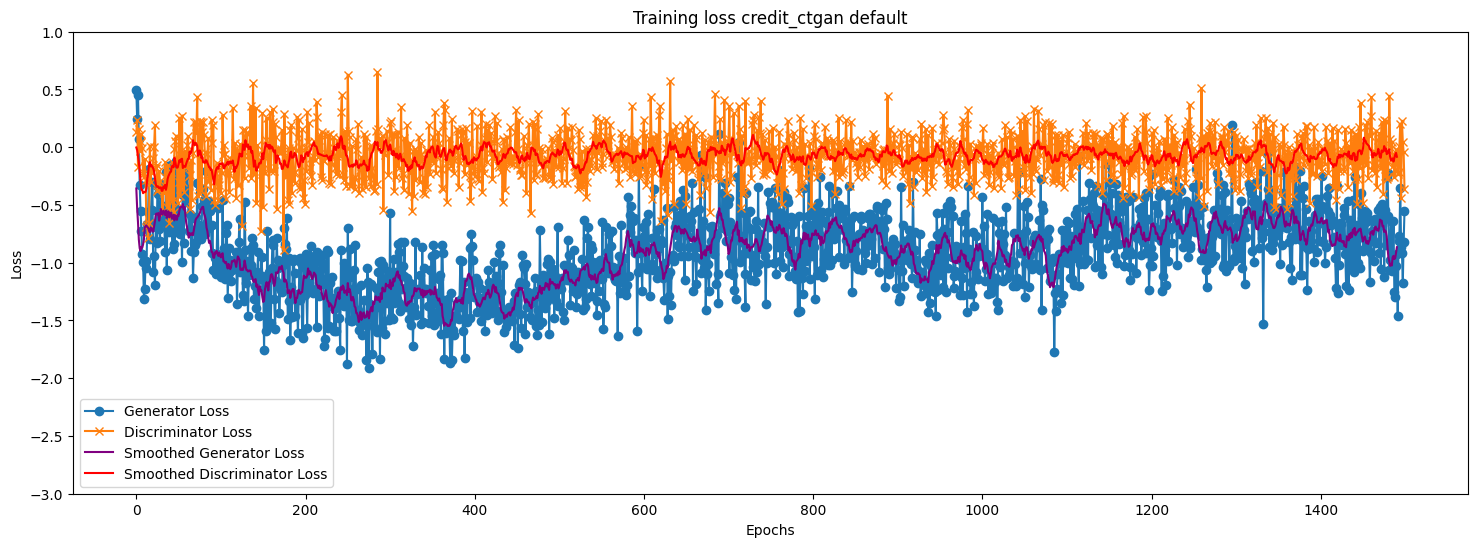

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Example lists for x, y1, and y2 values
x_values = results._training_report['Epoch']
y1_values = results._training_report['Generator Loss'] # First set of y-values
y2_values = results._training_report['Discriminator Loss']  # Second set of y-values

# Define a moving average function
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Create the plot
plt.figure(figsize=(18, 6))

# Plot the first line
plt.plot(x_values, y1_values, label='Generator Loss', marker='o')

# Plot the second line
plt.plot(x_values, y2_values, label='Discriminator Loss', marker='x')

window_size = 10  # Adjust the window size based on the number of epochs
smoothed_gen_loss = moving_average(y1_values, window_size)
smoothed_disc_loss = moving_average(y2_values, window_size)

plt.plot(smoothed_gen_loss, label='Smoothed Generator Loss', color='purple')
plt.plot(smoothed_disc_loss, label='Smoothed Discriminator Loss', color='red')

# Plot the third line
plt.ylim(-3, 1)  
# Add titles and labels
plt.title('Training loss credit_ctgan default')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# Show legend
plt.legend()

### tvae credit card default parameter 

In [3]:
import pickle
with open(f"{GENERATOR_OPTIMIZATION_DIR}/credit_tvae_simple_model.pkl", 'rb') as file:
    # Deserialize the object from the file
    results = pickle.load(file)

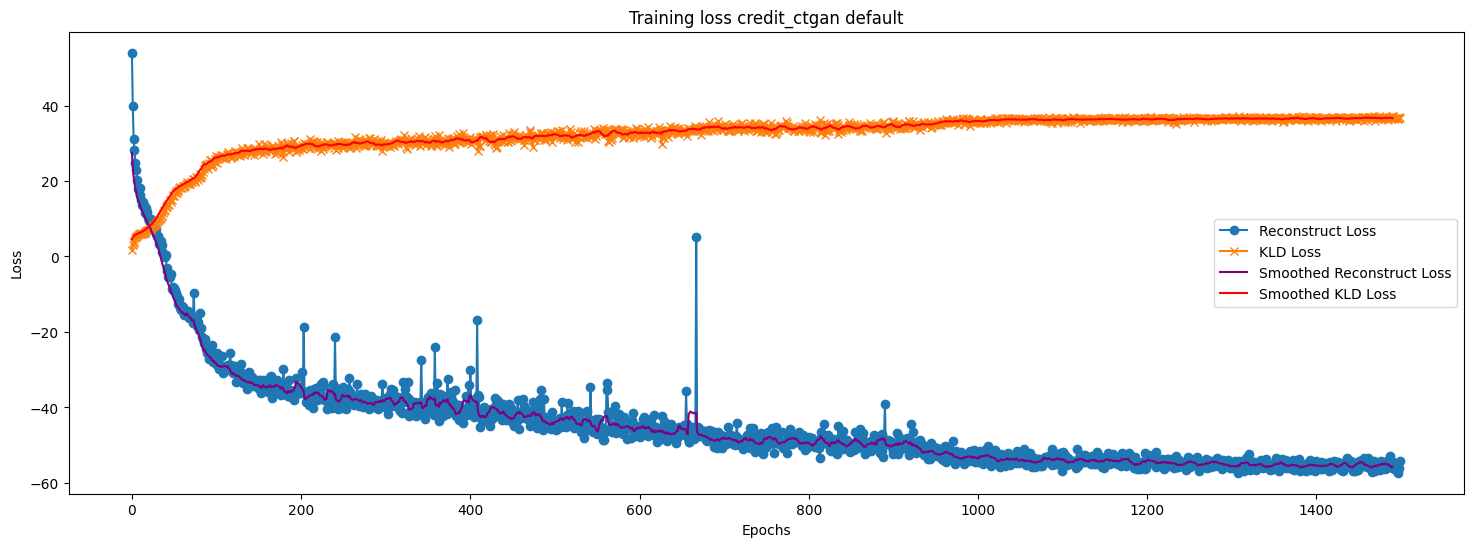

In [5]:
import matplotlib.pyplot as plt
import numpy as np
# Example lists for x, y1, and y2 values
x_values = results._training_report['Epoch']
y1_values = results._training_report['Reconstruct Loss'] # First set of y-values
y2_values = results._training_report['KLD Loss']  # Second set of y-values

# Define a moving average function
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Create the plot
plt.figure(figsize=(18, 6))

# Plot the first line
plt.plot(x_values, y1_values, label='Reconstruct Loss', marker='o')

# Plot the second line
plt.plot(x_values, y2_values, label='KLD Loss', marker='x')

window_size = 10  # Adjust the window size based on the number of epochs
smoothed_gen_loss = moving_average(y1_values, window_size)
smoothed_disc_loss = moving_average(y2_values, window_size)

plt.plot(smoothed_gen_loss, label='Smoothed Reconstruct Loss', color='purple')
plt.plot(smoothed_disc_loss, label='Smoothed KLD Loss', color='red')

# Plot the third line

# Add titles and labels
plt.title('Training loss credit_ctgan default')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# Show legend
plt.legend()

### ctgan credit card optimized parameter

In [6]:
import pickle
with open(f"{GENERATOR_OPTIMIZATION_DIR}/credit_ctgan_optimised_model.pkl", 'rb') as file:
    # Deserialize the object from the file
    results = pickle.load(file)

In [12]:
print(min(results._training_report['Generator Loss']))
print(np.argmin(results._training_report['Generator Loss']))

-2.8723459243774414
85


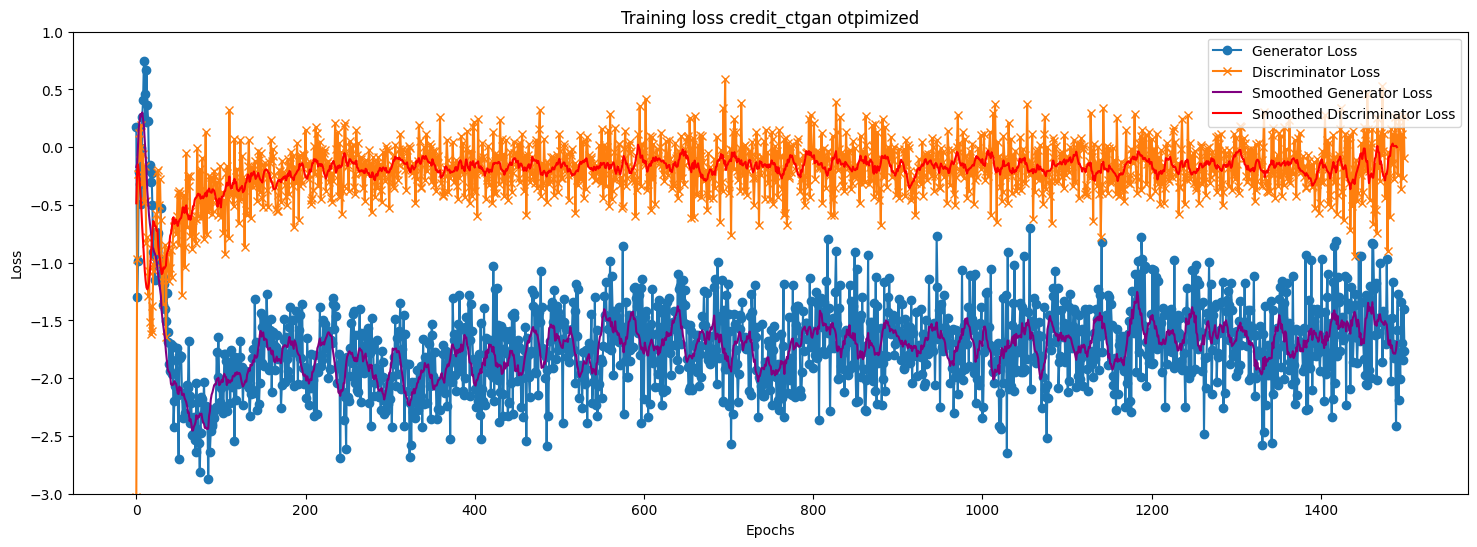

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Example lists for x, y1, and y2 values
x_values = results._training_report['Epoch']
y1_values = results._training_report['Generator Loss'] # First set of y-values
y2_values = results._training_report['Discriminator Loss']  # Second set of y-values

# Define a moving average function
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Create the plot
plt.figure(figsize=(18, 6))

# Plot the first line
plt.plot(x_values, y1_values, label='Generator Loss', marker='o')

# Plot the second line
plt.plot(x_values, y2_values, label='Discriminator Loss', marker='x')

window_size = 10  # Adjust the window size based on the number of epochs
smoothed_gen_loss = moving_average(y1_values, window_size)
smoothed_disc_loss = moving_average(y2_values, window_size)

plt.plot(smoothed_gen_loss, label='Smoothed Generator Loss', color='purple')
plt.plot(smoothed_disc_loss, label='Smoothed Discriminator Loss', color='red')
plt.ylim(-3, 1)  
# Plot the third line

# Add titles and labels
plt.title('Training loss credit_ctgan otpimized')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# Show legend
plt.legend()

### ctgan credit card optimized parameter 40 epochs

In [8]:
import pickle
with open(f"{GENERATOR_OPTIMIZATION_DIR}/credit_ctgan_optimized_model_40.pkl", 'rb') as file:
    # Deserialize the object from the file
    results = pickle.load(file)

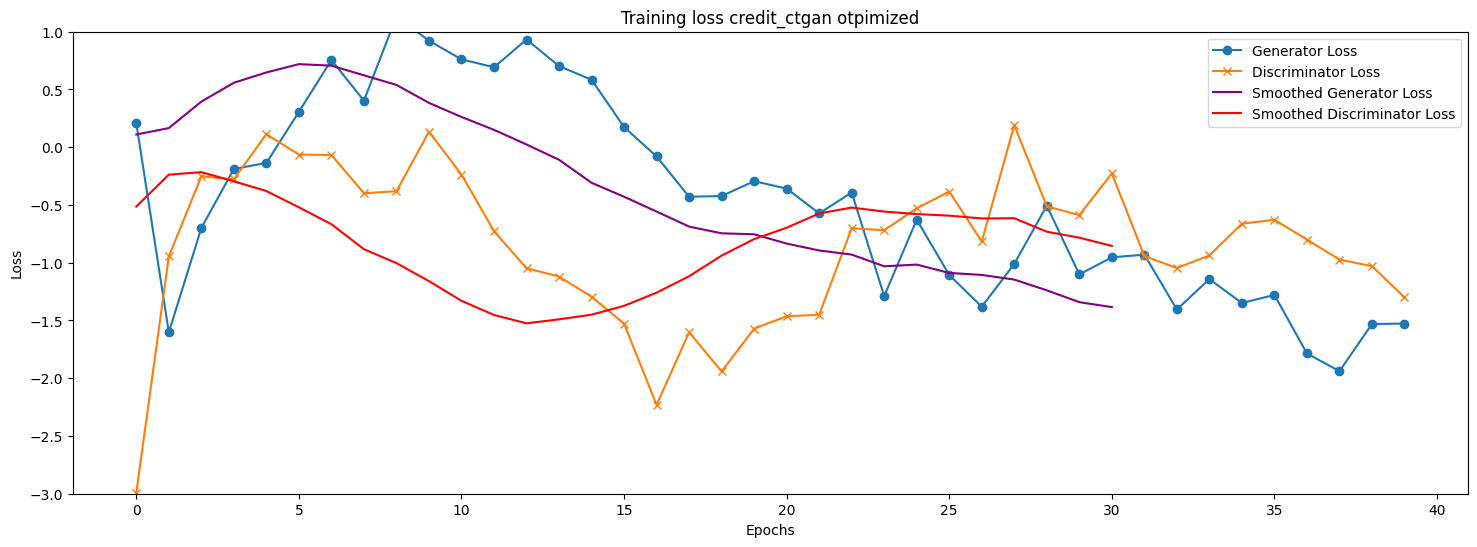

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Example lists for x, y1, and y2 values
x_values = results._training_report['Epoch']
y1_values = results._training_report['Generator Loss'] # First set of y-values
y2_values = results._training_report['Discriminator Loss']  # Second set of y-values

# Define a moving average function
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Create the plot
plt.figure(figsize=(18, 6))

# Plot the first line
plt.plot(x_values, y1_values, label='Generator Loss', marker='o')

# Plot the second line
plt.plot(x_values, y2_values, label='Discriminator Loss', marker='x')

window_size = 10  # Adjust the window size based on the number of epochs
smoothed_gen_loss = moving_average(y1_values, window_size)
smoothed_disc_loss = moving_average(y2_values, window_size)

plt.plot(smoothed_gen_loss, label='Smoothed Generator Loss', color='purple')
plt.plot(smoothed_disc_loss, label='Smoothed Discriminator Loss', color='red')
plt.ylim(-3, 1)  
# Plot the third line

# Add titles and labels
plt.title('Training loss credit_ctgan otpimized')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# Show legend
plt.legend()

### ctgan credit card optimized parameter 200 epochs

In [10]:
import pickle
with open(f"{GENERATOR_OPTIMIZATION_DIR}/credit_ctgan_optimized_model_400_early.pkl", 'rb') as file:
    # Deserialize the object from the file
    results = pickle.load(file)

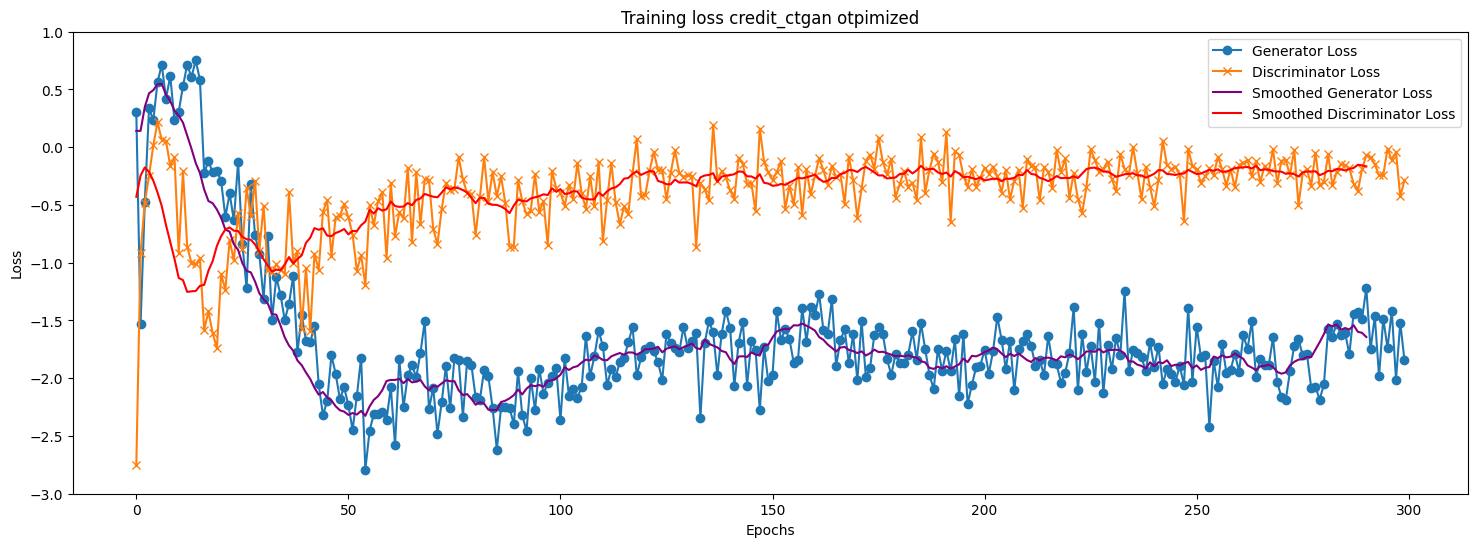

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Example lists for x, y1, and y2 values
x_values = results._training_report['Epoch']
y1_values = results._training_report['Generator Loss'] # First set of y-values
y2_values = results._training_report['Discriminator Loss']  # Second set of y-values

# Define a moving average function
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Create the plot
plt.figure(figsize=(18, 6))

# Plot the first line
plt.plot(x_values, y1_values, label='Generator Loss', marker='o')

# Plot the second line
plt.plot(x_values, y2_values, label='Discriminator Loss', marker='x')

window_size = 10  # Adjust the window size based on the number of epochs
smoothed_gen_loss = moving_average(y1_values, window_size)
smoothed_disc_loss = moving_average(y2_values, window_size)

plt.plot(smoothed_gen_loss, label='Smoothed Generator Loss', color='purple')
plt.plot(smoothed_disc_loss, label='Smoothed Discriminator Loss', color='red')
plt.ylim(-3, 1)  
# Plot the third line

# Add titles and labels
plt.title('Training loss credit_ctgan otpimized')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# Show legend
plt.legend()

In [15]:
results._model._generator.

<generator object Module.parameters at 0x7fef64fc3890>

In [19]:
results._model._early_stopping.best_loss

tensor(-2.7916)

In [18]:
min(results._training_report['Generator Loss'])

-2.79156494140625

### ctgan cardio default parameter

In [11]:
with open(f"{GENERATOR_OPTIMIZATION_DIR}/cardio_ctgan_simple_model.pkl", 'rb') as file:
    # Deerialize the object from the file
    results = pickle.load(file)

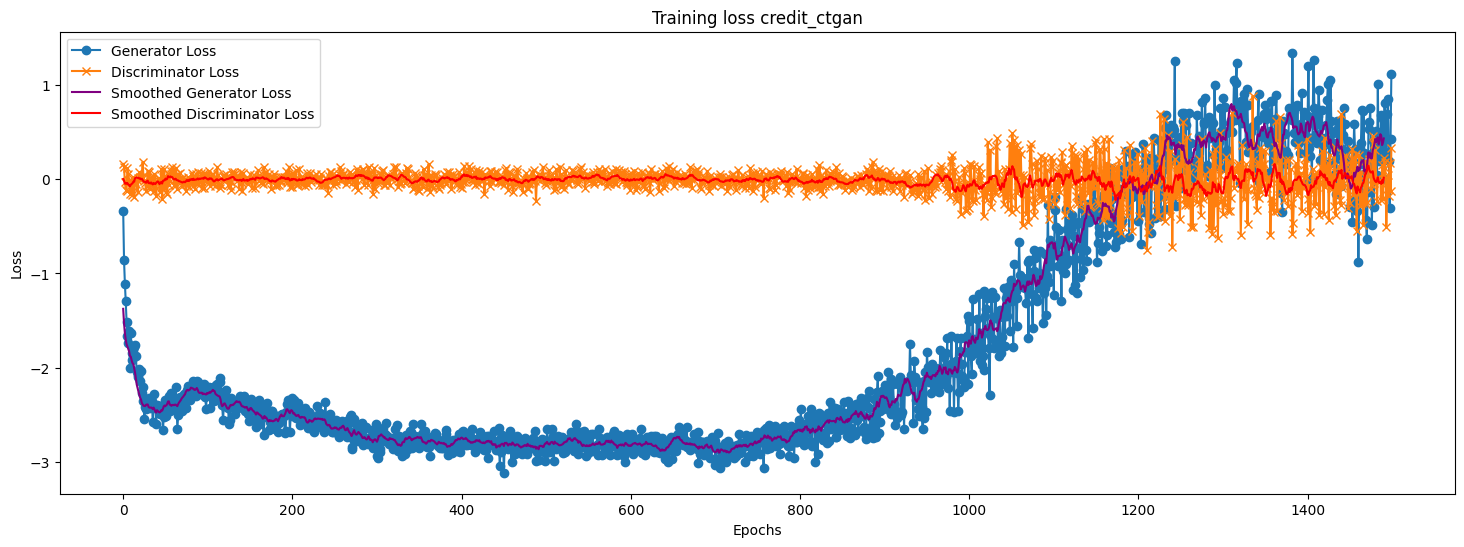

In [19]:
import matplotlib.pyplot as plt

# Example lists for x, y1, and y2 values
x_values = results._training_report['Epoch']
y1_values = results._training_report['Generator Loss'] # First set of y-values
y2_values = results._training_report['Discriminator Loss']  # Second set of y-values

# Define a moving average function
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Create the plot
plt.figure(figsize=(18, 6))

# Plot the first line
plt.plot(x_values, y1_values, label='Generator Loss', marker='o')

# Plot the second line
plt.plot(x_values, y2_values, label='Discriminator Loss', marker='x')

window_size = 10  # Adjust the window size based on the number of epochs
smoothed_gen_loss = moving_average(y1_values, window_size)
smoothed_disc_loss = moving_average(y2_values, window_size)

plt.plot(smoothed_gen_loss, label='Smoothed Generator Loss', color='purple')
plt.plot(smoothed_disc_loss, label='Smoothed Discriminator Loss', color='red')

# Plot the third line

# Add titles and labels
plt.title('Training loss credit_ctgan')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# Show legend
plt.legend()

### ctgan cardio optimized parameter

In [12]:
with open(f"{GENERATOR_OPTIMIZATION_DIR}/cardio_ctgan_optimized_model.pkl", 'rb') as file:
    # Deerialize the object from the file
    results = pickle.load(file)

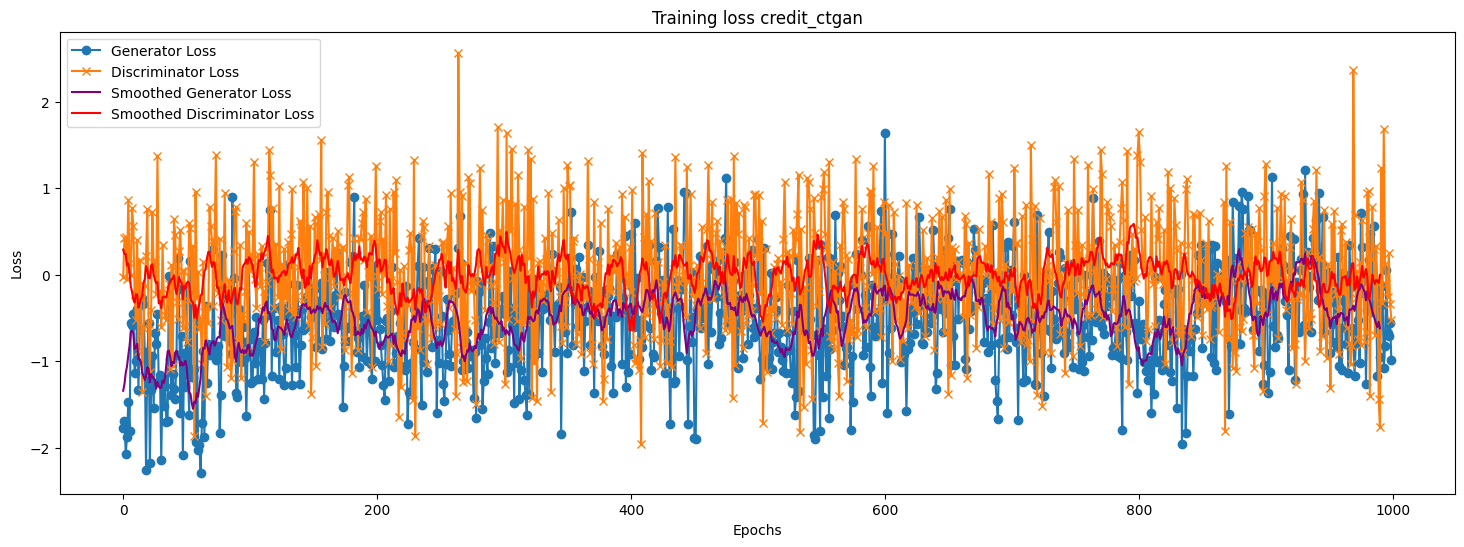

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Example lists for x, y1, and y2 values
x_values = results._training_report['Epoch']
y1_values = results._training_report['Generator Loss'] # First set of y-values
y2_values = results._training_report['Discriminator Loss']  # Second set of y-values

# Define a moving average function
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Create the plot
plt.figure(figsize=(18, 6))

# Plot the first line
plt.plot(x_values, y1_values, label='Generator Loss', marker='o')

# Plot the second line
plt.plot(x_values, y2_values, label='Discriminator Loss', marker='x')

window_size = 10  # Adjust the window size based on the number of epochs
smoothed_gen_loss = moving_average(y1_values, window_size)
smoothed_disc_loss = moving_average(y2_values, window_size)

plt.plot(smoothed_gen_loss, label='Smoothed Generator Loss', color='purple')
plt.plot(smoothed_disc_loss, label='Smoothed Discriminator Loss', color='red')

# Plot the third line

# Add titles and labels
plt.title('Training loss credit_ctgan')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# Show legend
plt.legend()

### tvae cardio default parameter 

In [13]:
with open(f"{GENERATOR_OPTIMIZATION_DIR}/cardio_tvae_simple_model.pkl", 'rb') as file:
    # Deserialize the object from the file
    results = pickle.load(file)

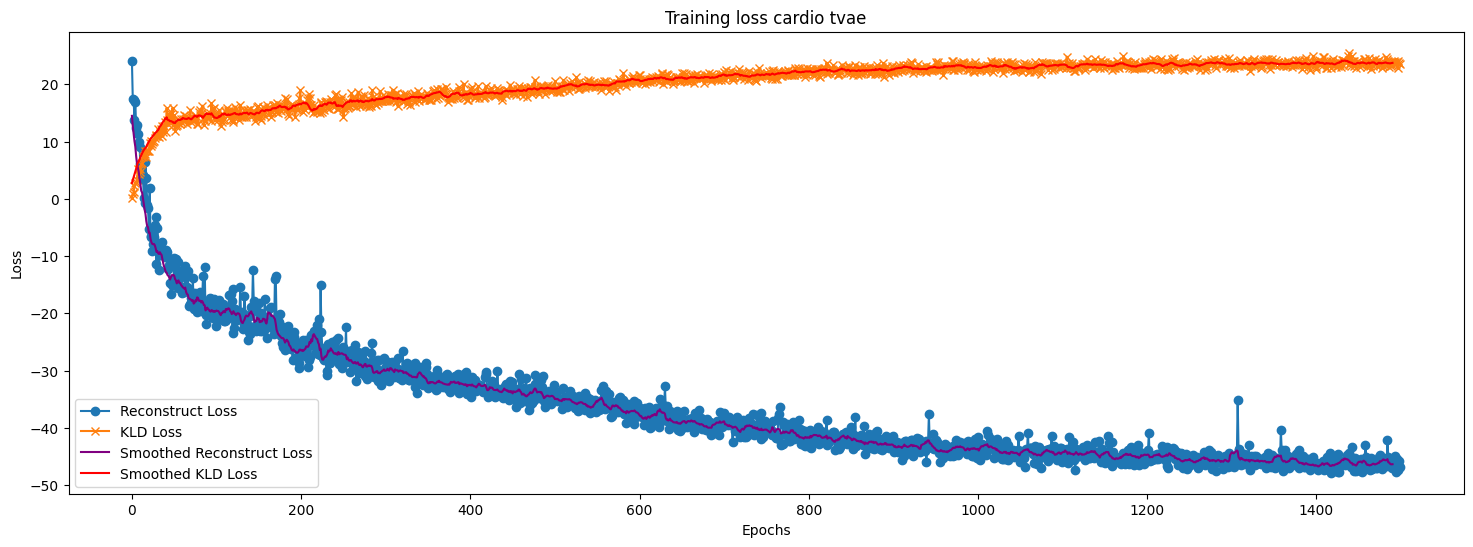

In [23]:
import matplotlib.pyplot as plt

# Example lists for x, y1, and y2 values
x_values = results._training_report['Epoch']
y1_values = results._training_report['Reconstruct Loss'] # First set of y-values
y2_values = results._training_report['KLD Loss']  # Second set of y-values

# Define a moving average function
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Create the plot
plt.figure(figsize=(18, 6))

# Plot the first line
plt.plot(x_values, y1_values, label='Reconstruct Loss', marker='o')

# Plot the second line
plt.plot(x_values, y2_values, label='KLD Loss', marker='x')

window_size = 10  # Adjust the window size based on the number of epochs
smoothed_gen_loss = moving_average(y1_values, window_size)
smoothed_disc_loss = moving_average(y2_values, window_size)

plt.plot(smoothed_gen_loss, label='Smoothed Reconstruct Loss', color='purple')
plt.plot(smoothed_disc_loss, label='Smoothed KLD Loss', color='red')

# Plot the third line

# Add titles and labels
plt.title('Training loss cardio tvae')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# Show legend
plt.legend()

### tvae cardio optimized parameter 

In [14]:
with open(f"{GENERATOR_OPTIMIZATION_DIR}/cardio_tvae_optimised_model.pkl", 'rb') as file:
    # Deserialize the object from the file
    results = pickle.load(file)

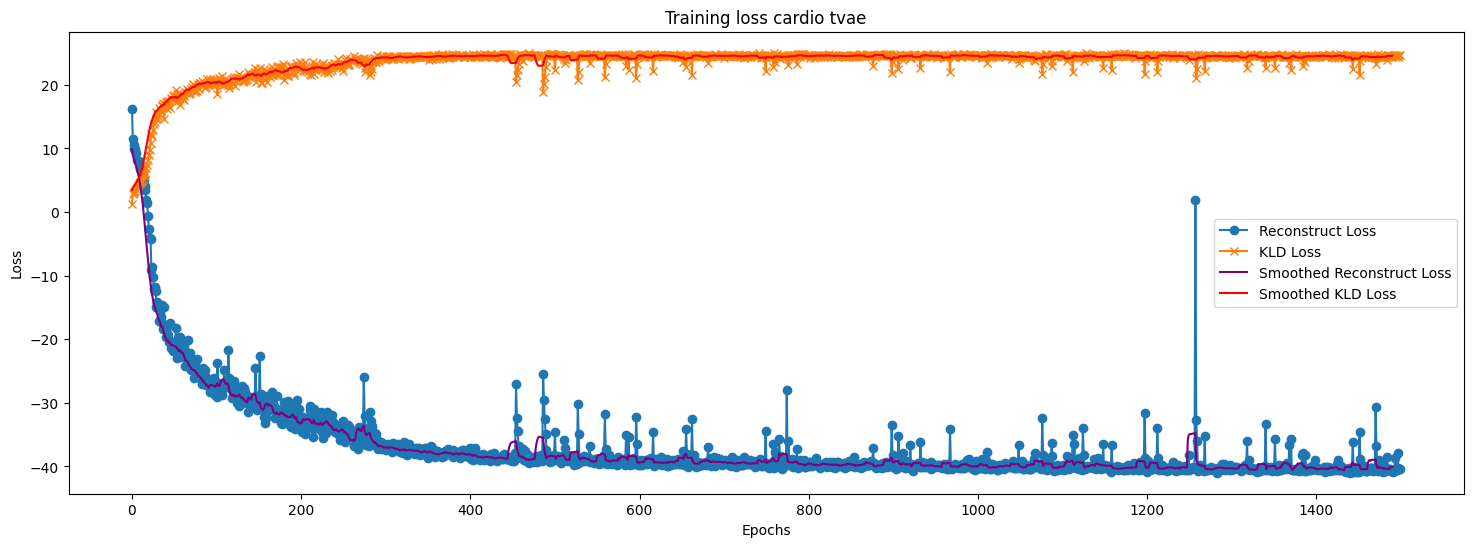

In [6]:
import matplotlib.pyplot as plt

# Example lists for x, y1, and y2 values
x_values = results._training_report['Epoch']
y1_values = results._training_report['Reconstruct Loss'] # First set of y-values
y2_values = results._training_report['KLD Loss']  # Second set of y-values

# Define a moving average function
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Create the plot
plt.figure(figsize=(18, 6))

# Plot the first line
plt.plot(x_values, y1_values, label='Reconstruct Loss', marker='o')

# Plot the second line
plt.plot(x_values, y2_values, label='KLD Loss', marker='x')

window_size = 10  # Adjust the window size based on the number of epochs
smoothed_gen_loss = moving_average(y1_values, window_size)
smoothed_disc_loss = moving_average(y2_values, window_size)

plt.plot(smoothed_gen_loss, label='Smoothed Reconstruct Loss', color='purple')
plt.plot(smoothed_disc_loss, label='Smoothed KLD Loss', color='red')

# Plot the third line

# Add titles and labels
plt.title('Training loss cardio tvae')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# Show legend
plt.legend()

### ctgan adult default parameter

In [15]:
with open(f"{GENERATOR_OPTIMIZATION_DIR}/adult_ctgan_simple_model.pkl", 'rb') as file:
    # Deserialize the object from the file
    results = pickle.load(file)

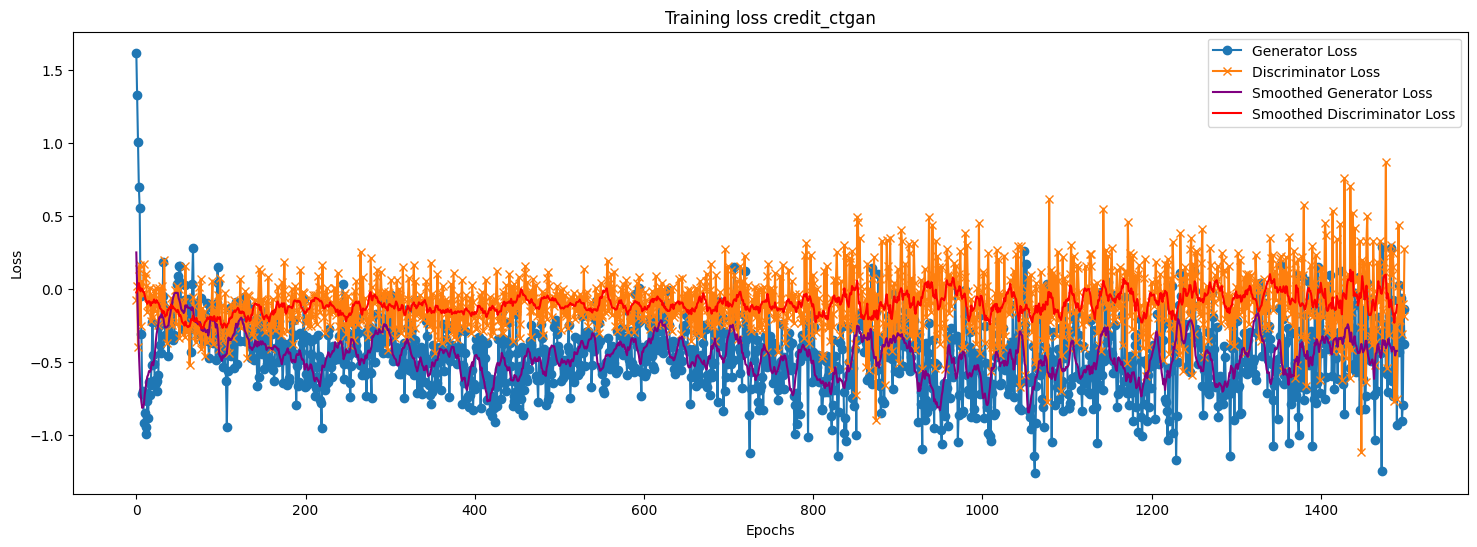

In [10]:
import matplotlib.pyplot as plt

# Example lists for x, y1, and y2 values
x_values = results._training_report['Epoch']
y1_values = results._training_report['Generator Loss'] # First set of y-values
y2_values = results._training_report['Discriminator Loss']  # Second set of y-values

# Define a moving average function
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Create the plot
plt.figure(figsize=(18, 6))

# Plot the first line
plt.plot(x_values, y1_values, label='Generator Loss', marker='o')

# Plot the second line
plt.plot(x_values, y2_values, label='Discriminator Loss', marker='x')

window_size = 10  # Adjust the window size based on the number of epochs
smoothed_gen_loss = moving_average(y1_values, window_size)
smoothed_disc_loss = moving_average(y2_values, window_size)

plt.plot(smoothed_gen_loss, label='Smoothed Generator Loss', color='purple')
plt.plot(smoothed_disc_loss, label='Smoothed Discriminator Loss', color='red')

# Plot the third line

# Add titles and labels
plt.title('Training loss credit_ctgan')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# Show legend
plt.legend()

### tvae adult default parameter 

In [16]:
with open(f"{GENERATOR_OPTIMIZATION_DIR}/adult_tvae_simple_model.pkl", 'rb') as file:
    # Deserialize the object from the file
    results = pickle.load(file)

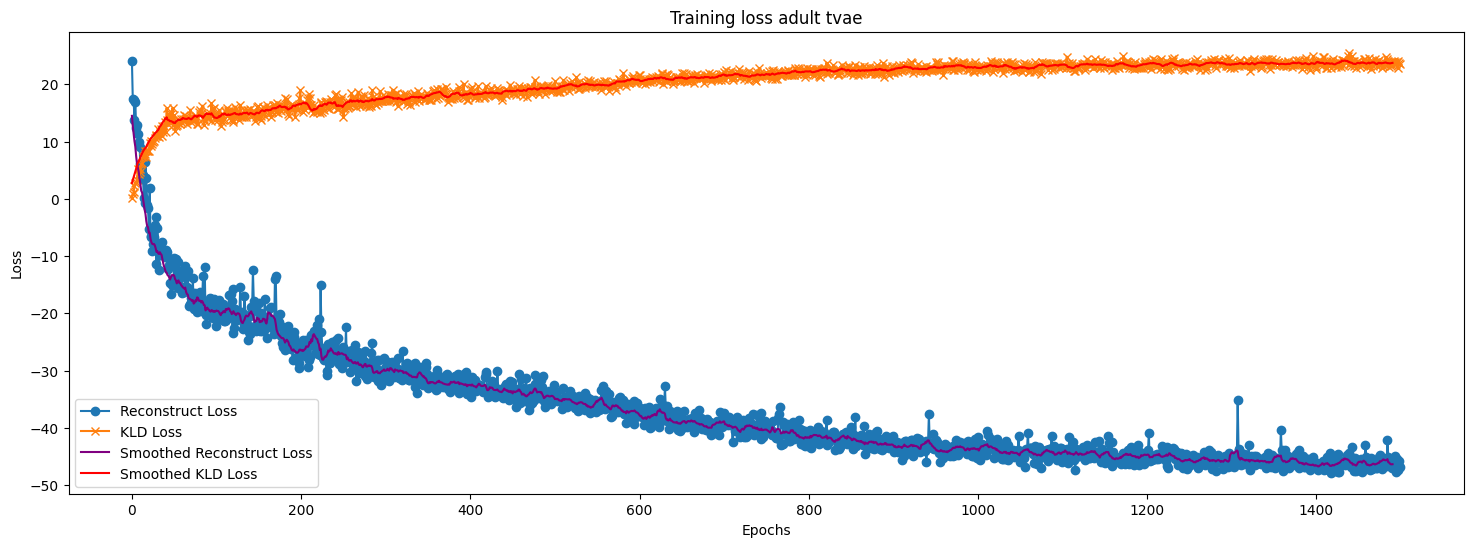

In [22]:
import matplotlib.pyplot as plt

# Example lists for x, y1, and y2 values
x_values = results._training_report['Epoch']
y1_values = results._training_report['Reconstruct Loss'] # First set of y-values
y2_values = results._training_report['KLD Loss']  # Second set of y-values

# Define a moving average function
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Create the plot
plt.figure(figsize=(18, 6))

# Plot the first line
plt.plot(x_values, y1_values, label='Reconstruct Loss', marker='o')

# Plot the second line
plt.plot(x_values, y2_values, label='KLD Loss', marker='x')

window_size = 10  # Adjust the window size based on the number of epochs
smoothed_gen_loss = moving_average(y1_values, window_size)
smoothed_disc_loss = moving_average(y2_values, window_size)

plt.plot(smoothed_gen_loss, label='Smoothed Reconstruct Loss', color='purple')
plt.plot(smoothed_disc_loss, label='Smoothed KLD Loss', color='red')

# Plot the third line

# Add titles and labels
plt.title('Training loss adult tvae')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# Show legend
plt.legend()

### ctgan adult optimized parameter 

In [17]:
import pickle
with open(f"{GENERATOR_OPTIMIZATION_DIR}/adult_ctgan_optimized_model.pkl", 'rb') as file:
    # Deserialize the object from the file
    results = pickle.load(file)

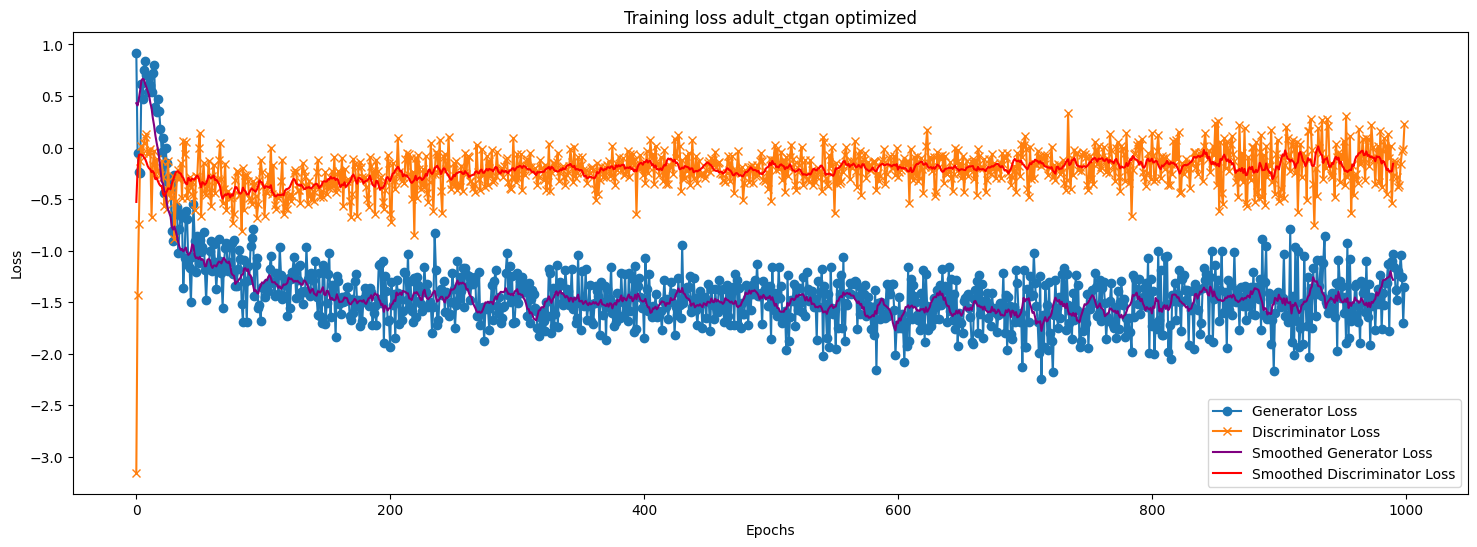

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Example lists for x, y1, and y2 values
x_values = results._training_report['Epoch']
y1_values = results._training_report['Generator Loss'] # First set of y-values
y2_values = results._training_report['Discriminator Loss']  # Second set of y-values

# Define a moving average function
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Create the plot
plt.figure(figsize=(18, 6))

# Plot the first line
plt.plot(x_values, y1_values, label='Generator Loss', marker='o')

# Plot the second line
plt.plot(x_values, y2_values, label='Discriminator Loss', marker='x')

window_size = 10  # Adjust the window size based on the number of epochs
smoothed_gen_loss = moving_average(y1_values, window_size)
smoothed_disc_loss = moving_average(y2_values, window_size)

plt.plot(smoothed_gen_loss, label='Smoothed Generator Loss', color='purple')
plt.plot(smoothed_disc_loss, label='Smoothed Discriminator Loss', color='red')

# Plot the third line

# Add titles and labels
plt.title('Training loss adult_ctgan optimized')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# Show legend
plt.legend()

In [18]:
import pickle
with open(f"{GENERATOR_OPTIMIZATION_DIR}/cardio_ctgan_optimized_model.pkl", 'rb') as file:
    # Deserialize the object from the file
    results = pickle.load(file)

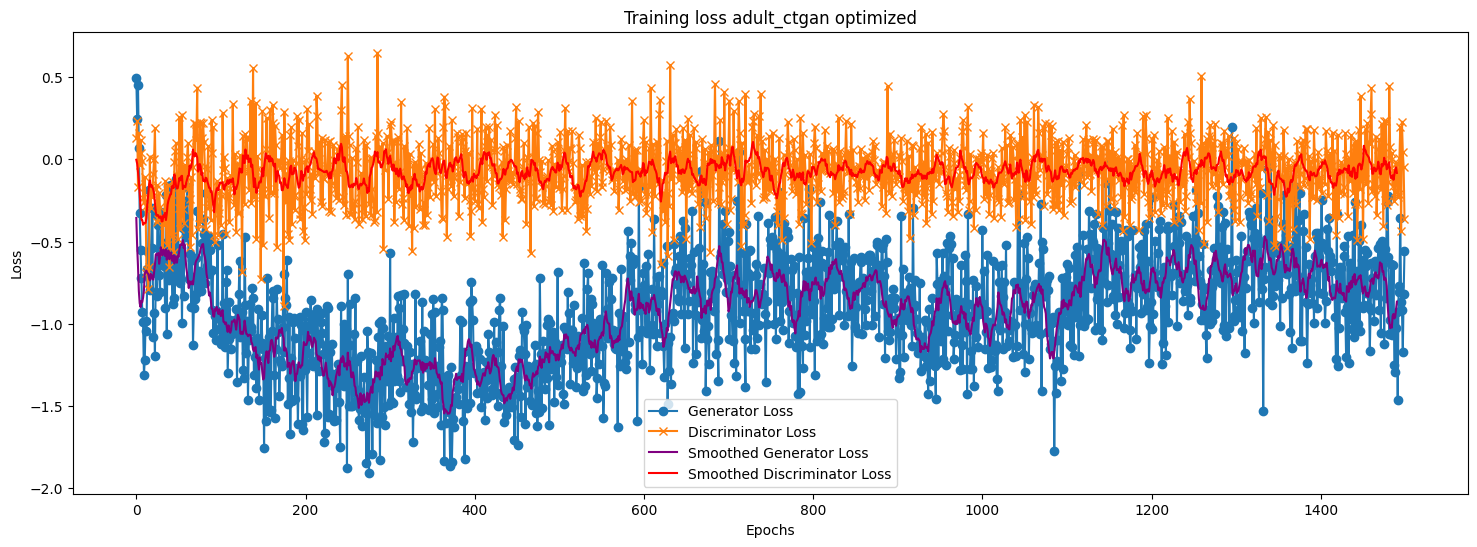

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Example lists for x, y1, and y2 values
x_values = results._training_report['Epoch']
y1_values = results._training_report['Generator Loss'] # First set of y-values
y2_values = results._training_report['Discriminator Loss']  # Second set of y-values

# Define a moving average function
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Create the plot
plt.figure(figsize=(18, 6))

# Plot the first line
plt.plot(x_values, y1_values, label='Generator Loss', marker='o')

# Plot the second line
plt.plot(x_values, y2_values, label='Discriminator Loss', marker='x')

window_size = 10  # Adjust the window size based on the number of epochs
smoothed_gen_loss = moving_average(y1_values, window_size)
smoothed_disc_loss = moving_average(y2_values, window_size)

plt.plot(smoothed_gen_loss, label='Smoothed Generator Loss', color='purple')
plt.plot(smoothed_disc_loss, label='Smoothed Discriminator Loss', color='red')

# Plot the third line

# Add titles and labels
plt.title('Training loss cardio_ctgan optimized')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# Show legend
plt.legend()

## HYperTuning

### Optuna best param credit ctgan

In [ ]:
from experiments.scripts.optuna.load_legacy_optuna_pickle import load_study

results = load_study(f"{OPTUNA_DIR}/study_ctgan_credit.pkl")


50 trials


In [4]:
import pickle
with open(f"{OPTUNA_DIR}/study_ctgan_credit.pkl", 'rb') as file:
    # Deserialize the object from the file
    results = pickle.load(file)


TypeError: _ParzenEstimatorParameters.__new__() takes 7 positional arguments but 8 were given

In [10]:
print('best_params : ', results.best_params)
print('best_value : ', results.best_value)

best_params :  {'embedding_dim': 128, 'generator_lr': 5.939177101221521e-05, 'discriminator_lr': 0.00019841154045204687, 'generator_dim': [256, 256], 'discriminator_dim': [512, 512], 'batch_size': 500, 'epochs': 1500}
best_value :  0.004004156333296094


### Optuna best param credit tvae

In [11]:
results = load_study(f"{OPTUNA_DIR}/study_tvae_credit.pkl")

In [ ]:
import pickle
with open(f"{OPTUNA_DIR}/study_tvae_credit.pkl", 'rb') as file:
    # Deserialize the object from the file
    results = pickle.load(file)

In [12]:
print('best_params : ', results.best_params)
print('best_value : ', results.best_value)

best_params :  {'embedding_dim': 256, 'generator_dim': [512, 512], 'discriminator_dim': [512, 512], 'batch_size': 1000, 'epochs': 1000}
best_value :  0.00011775728687207776


### Optuna best param adult tvae

In [14]:
results = load_study(f"{OPTUNA_DIR}/study_tvae_adult.pkl")

In [5]:
import pickle
with open(f"{OPTUNA_DIR}/study_tvae_adult.pkl", 'rb') as file:
    # Deserialize the object from the file
    results = pickle.load(file)


TypeError: _ParzenEstimatorParameters.__new__() takes 7 positional arguments but 8 were given

In [16]:
print('best_params : ', results.best_params)
print('best_value : ', results.best_value)

best_params :  {'embedding_dim': 128, 'generator_dim': [256, 512], 'discriminator_dim': [256, 512], 'batch_size': 1000, 'epochs': 1000}
best_value :  0.04107675117932408


### Optuna best param cardio tvae

In [18]:
results = load_study(f"{OPTUNA_DIR}/study_tvae_cardio.pkl")

print('best_params : ', results.best_params)
print('best_value : ', results.best_value)

best_params :  {'embedding_dim': 256, 'generator_dim': [256, 512], 'discriminator_dim': [256, 512], 'batch_size': 1000, 'epochs': 1500}
best_value :  0.012119930464787654


In [ ]:
import pickle
with open(f"{OPTUNA_DIR}/study_tvae_cardio.pkl", 'rb') as file:
    # Deserialize the object from the file
    results = pickle.load(file)

print('best_params : ', results.best_params)
print('best_value : ', results.best_value)

best_params :  {'embedding_dim': 256, 'generator_dim': [256, 512], 'discriminator_dim': [256, 512], 'batch_size': 1000, 'epochs': 1500}
best_value :  0.012119930464787654


### Optuna best param adult ctgan

In [19]:
results = load_study(f"{OPTUNA_DIR}/study_ctgan_adult.pkl")

print('best_params : ', results.best_params)
print('best_value : ', results.best_value)

best_params :  {'embedding_dim': 128, 'generator_lr': 4.079264779894101e-05, 'discriminator_lr': 0.00015153073112107783, 'generator_dim': [256, 512], 'discriminator_dim': [512, 512], 'batch_size': 500, 'epochs': 1000}
best_value :  0.037688024221283034


In [ ]:
import pickle
with open(f"{OPTUNA_DIR}/study_ctgan_adult.pkl", 'rb') as file:
    # Deserialize the object from the file
    results = pickle.load(file)

print('best_params : ', results.best_params)
print('best_value : ', results.best_value)

best_params :  {'embedding_dim': 128, 'generator_lr': 4.079264779894101e-05, 'discriminator_lr': 0.00015153073112107783, 'generator_dim': [256, 512], 'discriminator_dim': [512, 512], 'batch_size': 500, 'epochs': 1000}
best_value :  0.037688024221283034


### Optuna best param cardio ctgan

In [20]:
results = load_study(f"{OPTUNA_DIR}/study_ctgan_cardio.pkl")

print('best_params : ', results.best_params)
print('best_value : ', results.best_value)

best_params :  {'embedding_dim': 512, 'generator_lr': 0.00017403142604971523, 'discriminator_lr': 0.00037251120555768314, 'generator_dim': [256, 256], 'discriminator_dim': [256, 256], 'batch_size': 100, 'epochs': 1000}
best_value :  0.010636826252805709


In [16]:
import pickle
with open("../scripts/optuna/study_ctgan_cardio.pkl", 'rb') as file:
    # Deserialize the object from the file
    results = pickle.load(file)

print('best_params : ', results.best_params)
print('best_value : ', results.best_value)

best_params :  {'embedding_dim': 512, 'generator_lr': 0.00017403142604971523, 'discriminator_lr': 0.00037251120555768314, 'generator_dim': [256, 256], 'discriminator_dim': [256, 256], 'batch_size': 100, 'epochs': 1000}
best_value :  0.010636826252805709


In [10]:
import pickle
import pandas as pd

results_ctgan = {}
results_tvae = {}

with open("../scripts/optuna/study_ctgan_credit.pkl", 'rb') as file:
    # Deserialize the object from the file
    result = pickle.load(file)
    results_ctgan['ctgan_credit'] = result.best_params
with open("../scripts/optuna/study_tvae_credit.pkl", 'rb') as file:
    # Deserialize the object from the file
    result = pickle.load(file)
    results_tvae['tvae_credit'] = result.best_params
with open("../scripts/optuna/study_ctgan_cardio.pkl", 'rb') as file:
    # Deserialize the object from the file
    result = pickle.load(file)
    results_ctgan['ctgan_cardio'] = result.best_params
with open("../scripts/optuna/study_tvae_cardio.pkl", 'rb') as file:
    # Deserialize the object from the file
    result = pickle.load(file)
    results_tvae['tvae_cardio'] = result.best_params
with open("../scripts/optuna/study_ctgan_adult.pkl", 'rb') as file:
    # Deserialize the object from the file
    result = pickle.load(file)
    results_ctgan['ctgan_adult'] = result.best_params
with open("../scripts/optuna/study_tvae_adult.pkl", 'rb') as file:
    # Deserialize the object from the file
    result = pickle.load(file)
    results_tvae['tvae_adult'] = result.best_params

df_ctgan = pd.DataFrame(results_ctgan).T.reset_index().rename(columns={'index': 'model_dataset'})
df_tvae = pd.DataFrame(results_tvae).T.reset_index().rename(columns={'index': 'model_dataset'})

print("CTGAN results:\n", df_ctgan)
print("\nTVAE results:\n", df_tvae)



CTGAN results:
   model_dataset embedding_dim generator_lr discriminator_lr generator_dim  \
0  ctgan_credit           128     0.000059         0.000198    [256, 256]   
1  ctgan_cardio           512     0.000174         0.000373    [256, 256]   
2   ctgan_adult           128     0.000041         0.000152    [256, 512]   

  discriminator_dim batch_size epochs  
0        [512, 512]        500   1500  
1        [256, 256]        100   1000  
2        [512, 512]        500   1000  

TVAE results:
   model_dataset embedding_dim generator_dim discriminator_dim batch_size  \
0   tvae_credit           256    [512, 512]        [512, 512]       1000   
1   tvae_cardio           256    [256, 512]        [256, 512]       1000   
2    tvae_adult           128    [256, 512]        [256, 512]       1000   

  epochs  
0   1000  
1   1500  
2   1000  


In [11]:
df_ctgan

,model_dataset,embedding_dim,generator_lr,discriminator_lr,generator_dim,discriminator_dim,batch_size,epochs
0,ctgan_credit,128,0.000059,0.000198,"[256, 256]","[512, 512]",500,1500
1,ctgan_cardio,512,0.000174,0.000373,"[256, 256]","[256, 256]",100,1000
2,ctgan_adult,128,0.000041,0.000152,"[256, 512]","[512, 512]",500,1000


In [8]:
results_ctgan_adult.best_params

{'embedding_dim': 128,
 'generator_lr': 4.079264779894101e-05,
 'discriminator_lr': 0.00015153073112107783,
 'generator_dim': [256, 512],
 'discriminator_dim': [512, 512],
 'batch_size': 500,
 'epochs': 1000}

In [7]:
results_tvae_adult.best_params

{'embedding_dim': 128,
 'generator_dim': [256, 512],
 'discriminator_dim': [256, 512],
 'batch_size': 1000,
 'epochs': 1000}